# 02 — Synthetic GPS: локальний fusion pipeline

Це очищена локальна робоча версія експериментального Colab notebook. Вона
починається з уже підготовленого `K2R..._with_velocity.mcap`, у якому є
`/vision/velocity_frd`, і формує синтетичні координати між рідкісними
Starlink/GPS-вимірюваннями за допомогою IMU, barometer, optical-flow velocity
та GTSAM Fixed-Lag Smoother.

Порядок виконання:

1. перевірка Linux/ROS/Python і локальних шляхів;
2. витяг потрібних ROS topics у CSV;
3. калібрування часових затримок та ENU-нормалізація;
4. GTSAM fusion і збереження результатів.

Використовуй ядро **Project CV (ROS 2 Humble)** і виконуй клітинки зверху вниз.


## Межі цієї міграції

- Оригінальний `opticalflow_sparse_noised_gps_fusion_v1(1).ipynb` залишається
  незмінним референсом.
- Основна математика перенесена з original cells **33, 35, 37**.
- Optical-flow velocity тут не перераховується з кадрів: notebook читає готовий
  `/vision/velocity_frd` із derived MCAP, коригує його час, повертає FRD→ENU та
  використовує у fusion.
- In calibration/GTSAM, local paths and static-typing boundaries were adapted.
  Parameters, formulas, factors, delays, and operation order are unchanged.
- A stale Colab description was omitted because it differed from the actual initialization in cell 37 and could be misleading.
- Colab provisioning, Google Drive, `/content`, порожні/дубльовані клітинки та
  upstream rebuild raw→LK→velocity не входять у цей робочий сценарій.
- Raw і derived bag вважаються read-only; усі результати йдуть у
  `PROJECT_CV_ARTIFACTS/fusion_v1` всередині WSL.


## 0. Runtime і локальні шляхи


In [9]:
import importlib.metadata as importlib_metadata
import os
import platform
import sys

import cv2
import gtsam
import gtsam_unstable
import matplotlib
import numpy as np
import pandas as pd
import rosbag2_py
import yaml

assert platform.system() == "Linux", (
    "Select the 'Project CV (ROS 2 Humble)' kernel; "
    f"the current kernel reports {platform.system()}."
)
assert sys.version_info[:2] == (3, 10), platform.python_version()
assert os.environ.get("ROS_DISTRO") == "humble", os.environ.get("ROS_DISTRO")

fixed_lag_classes = ("IncrementalFixedLagSmoother", "BatchFixedLagSmoother")
assert any(hasattr(gtsam_unstable, name) for name in fixed_lag_classes)

runtime_versions = {
    "Python": platform.python_version(),
    "ROS": os.environ["ROS_DISTRO"],
    "NumPy": np.__version__,
    "OpenCV": cv2.__version__,
    "pandas": importlib_metadata.version("pandas"),
    "matplotlib": matplotlib.__version__,
}

for name, value in runtime_versions.items():
    print(f"{name:12s}: {value}")
print("GTSAM module:", gtsam.__name__)
print("rosbag2_py module:", rosbag2_py.__name__)
print("PyYAML module:", yaml.__name__)
print("ROS 2 Python imports: OK")
print("GTSAM fixed-lag bindings: OK")


Python      : 3.10.12
ROS         : humble
NumPy       : 1.26.4
OpenCV      : 4.5.4
pandas      : 2.2.3
matplotlib  : 3.10.0
GTSAM module: gtsam
rosbag2_py module: rosbag2_py
PyYAML module: yaml
ROS 2 Python imports: OK
GTSAM fixed-lag bindings: OK


In [10]:
from pathlib import Path


def required_env_path(name: str) -> Path:
    value = os.environ.get(name)
    assert value, f"Missing environment variable: {name}"
    return Path(value)


PROJECT_ROOT = required_env_path("PROJECT_CV_SOURCE")
RUNTIME_ROOT = required_env_path("PROJECT_CV_RUNTIME")
RAW_BAG_DIR = required_env_path("PROJECT_CV_RAW_BAG")
INPUT_BAG_DIR = required_env_path("PROJECT_CV_DERIVED_BAG")
CALIBRATION_DIR = required_env_path("PROJECT_CV_CALIBRATION")
ARTIFACTS_ROOT = required_env_path("PROJECT_CV_ARTIFACTS")

THERMAL_CALIB_FILE = CALIBRATION_DIR / "thermal_camera.yml"
CAM_TO_IMU_FILE = CALIBRATION_DIR / "cam_to_imu_rot_mtrx.yml"

# All generated files stay outside the source bags.
RUN_ROOT = ARTIFACTS_ROOT / "fusion_v1"
EXTRACT_DIR = RUN_ROOT / "extract"
WORK_DIR = RUN_ROOT / "work"
FUSION_OUTPUT_DIR = RUN_ROOT / "gtsam"

required_paths = (
    PROJECT_ROOT,
    RUNTIME_ROOT,
    RAW_BAG_DIR / "metadata.yaml",
    RAW_BAG_DIR / "K2R00005_20260607_194949_0.mcap",
    INPUT_BAG_DIR / "metadata.yaml",
    INPUT_BAG_DIR / "K2R00005_20260607_194949_with_velocity.mcap",
    THERMAL_CALIB_FILE,
    CAM_TO_IMU_FILE,
    ARTIFACTS_ROOT,
)
missing_paths = [str(path) for path in required_paths if not path.exists()]
assert not missing_paths, f"Missing runtime paths: {missing_paths}"

input_roots = (RAW_BAG_DIR.resolve(), INPUT_BAG_DIR.resolve())
for output_dir in (RUN_ROOT, EXTRACT_DIR, WORK_DIR, FUSION_OUTPUT_DIR):
    resolved_output = output_dir.resolve()
    assert all(root not in (resolved_output, *resolved_output.parents) for root in input_roots)

print("Input derived bag :", INPUT_BAG_DIR)
print("Calibration       :", CALIBRATION_DIR)
print("Run artifacts     :", RUN_ROOT)
print("Source bags are treated as read-only.")


Input derived bag : /home/fedor/project_cv_runtime/bags/derived_velocity
Calibration       : /home/fedor/project_cv_runtime/calibration
Run artifacts     : /home/fedor/project_cv_runtime/artifacts/fusion_v1
Source bags are treated as read-only.


In [11]:
from typing import Any, cast

from IPython.display import display

metadata_path = INPUT_BAG_DIR / "metadata.yaml"
metadata_document: object = yaml.safe_load(metadata_path.read_text(encoding="utf-8"))
if not isinstance(metadata_document, dict):
    raise TypeError(f"Expected a YAML mapping in {metadata_path}")
metadata = cast(dict[str, Any], metadata_document)

bag_info_document = metadata.get("rosbag2_bagfile_information")
if not isinstance(bag_info_document, dict):
    raise TypeError("metadata.yaml has no rosbag2_bagfile_information mapping")
bag_info = cast(dict[str, Any], bag_info_document)

assert bag_info["storage_identifier"] == "mcap"
assert int(bag_info["message_count"]) > 0

relative_files = [INPUT_BAG_DIR / name for name in bag_info["relative_file_paths"]]
missing_bag_files = [str(path) for path in relative_files if not path.exists()]
assert not missing_bag_files, f"Missing MCAP files: {missing_bag_files}"

topic_rows: list[dict[str, object]] = []
topic_types: dict[str, str] = {}
topic_counts: dict[str, int] = {}

for item in bag_info["topics_with_message_count"]:
    topic = item["topic_metadata"]
    topic_name = str(topic["name"])
    topic_type = str(topic["type"])
    message_count = int(item["message_count"])

    topic_types[topic_name] = topic_type
    topic_counts[topic_name] = message_count
    topic_rows.append(
        {
            "topic": topic_name,
            "type": topic_type,
            "messages": message_count,
        }
    )

topic_table = pd.DataFrame(topic_rows).sort_values(by="topic", ignore_index=True)

required_topic_types = {
    "/device/starlink/raw": "sensor_msgs/msg/NavSatFix",
    "/device/gps/raw": "sensor_msgs/msg/NavSatFix",
    "/imu/data_raw": "sensor_msgs/msg/Imu",
    "/imu/euler": "geometry_msgs/msg/Vector3Stamped",
    "/imu/pure_baro_alt": "std_msgs/msg/Float64",
    "/vision/velocity_frd": "geometry_msgs/msg/TwistStamped",
}

missing_topics = sorted(set(required_topic_types) - set(topic_types))
assert not missing_topics, f"Missing required topics: {missing_topics}"

wrong_types = {
    topic: {"expected": expected, "actual": topic_types[topic]}
    for topic, expected in required_topic_types.items()
    if topic_types[topic] != expected
}
assert not wrong_types, f"Unexpected topic types: {wrong_types}"

empty_topics = [
    topic for topic in required_topic_types
    if topic_counts[topic] <= 0
]
assert not empty_topics, f"Required topics have no messages: {empty_topics}"

display(topic_table)
print(
    f"Preflight OK: {bag_info['message_count']} messages, " +
    f"{len(topic_table)} topics, duration {bag_info['duration']['nanoseconds'] / 1e9:.3f} s"
)


,topic,type,messages
0,/camera/image_raw,sensor_msgs/msg/Image,0
1,/camera/image_raw/compressed,sensor_msgs/msg/CompressedImage,76967
2,/device/gps/raw,sensor_msgs/msg/NavSatFix,9202
3,/device/starlink/raw,sensor_msgs/msg/NavSatFix,142
4,/device/xps/fix,sensor_msgs/msg/NavSatFix,5438
5,/device/xps_sdl,std_msgs/msg/String,1197
6,/imu/data_raw,sensor_msgs/msg/Imu,256733
7,/imu/euler,geometry_msgs/msg/Vector3Stamped,256730
8,/imu/pure_baro_alt,std_msgs/msg/Float64,11918
9,/mavros/global_position/raw/fix,sensor_msgs/msg/NavSatFix,11917


Preflight OK: 790914 messages, 14 topics, duration 1283.768 s


## 1. Extract ROS topics → CSV

Локалізована оболонка original cell 33. У Colab вона створювала тимчасовий
Python-файл через `%%bash`; тут той самий Python-код виконується безпосередньо
правильним ROS-ядром. Вхідний MCAP не змінюється.


In [12]:
import csv, json

import rosbag2_py
from rclpy.serialization import deserialize_message
from rosidl_runtime_py.utilities import get_message

BAG_DIR = INPUT_BAG_DIR
OUT_DIR = EXTRACT_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

WANTED = [
    "/device/starlink/raw",
    "/device/gps/raw",
    "/imu/data_raw",
    "/imu/euler",
    "/imu/pure_baro_alt",
    "/vision/velocity_frd",
]

reader = rosbag2_py.SequentialReader()
reader.open(
    rosbag2_py.StorageOptions(
        uri=str(BAG_DIR),
        storage_id="mcap",
    ),
    rosbag2_py.ConverterOptions(
        input_serialization_format="cdr",
        output_serialization_format="cdr",
    ),
)

types = {t.name: t.type for t in reader.get_all_topics_and_types()}

print("Available wanted topics:")
for t in WANTED:
    print(f"  {t:35s}", types.get(t, "NOT FOUND"))

msg_types = {
    t: get_message(types[t])
    for t in WANTED
    if t in types
}


def msg_time(msg, bag_ns):
    """
    Повертає timestamp повідомлення.
    Якщо є header.stamp — беремо його.
    Інакше беремо bag timestamp.
    """
    if hasattr(msg, "header"):
        sec = int(msg.header.stamp.sec)
        ns = int(msg.header.stamp.nanosec)
        if sec or ns:
            return sec + ns * 1e-9, "header"

    return bag_ns * 1e-9, "bag"


def open_writer(topic, header):
    name = topic.strip("/").replace("/", "__")
    f = open(OUT_DIR / f"{name}.csv", "w", newline="")
    w = csv.DictWriter(f, fieldnames=header)
    w.writeheader()
    return f, w


files = {}
writers = {}

files["gps"], writers["gps"] = open_writer(
    "/device/gps/raw",
    [
        "t",
        "t_source",
        "bag_t",
        "lat",
        "lon",
        "alt",
        "status",
        "cov_x",
        "cov_y",
        "cov_z",
    ],
)

files["sl"], writers["sl"] = open_writer(
    "/device/starlink/raw",
    [
        "t",
        "t_source",
        "bag_t",
        "lat",
        "lon",
        "alt",
        "status",
        "cov_x",
        "cov_y",
        "cov_z",
    ],
)

files["imu"], writers["imu"] = open_writer(
    "/imu/data_raw",
    [
        "t",
        "t_source",
        "bag_t",
        "wx",
        "wy",
        "wz",
        "ax",
        "ay",
        "az",
        "qx",
        "qy",
        "qz",
        "qw",
    ],
)

files["eul"], writers["eul"] = open_writer(
    "/imu/euler",
    [
        "t",
        "t_source",
        "bag_t",
        "roll",
        "pitch",
        "yaw",
    ],
)

files["baro"], writers["baro"] = open_writer(
    "/imu/pure_baro_alt",
    [
        "t",
        "t_source",
        "bag_t",
        "alt",
    ],
)

files["vel"], writers["vel"] = open_writer(
    "/vision/velocity_frd",
    [
        "t",
        "t_source",
        "bag_t",
        "vx",
        "vy",
        "vz",
        "wx",
        "wy",
        "wz",
        "frame_id",
    ],
)

counts = {t: 0 for t in WANTED}

while reader.has_next():
    topic, data, bag_ns = reader.read_next()

    if topic not in msg_types:
        continue

    msg = deserialize_message(data, msg_types[topic])

    t, src = msg_time(msg, bag_ns)
    bag_t = bag_ns * 1e-9

    if topic in ["/device/gps/raw", "/device/starlink/raw"]:
        cov = list(msg.position_covariance)
        key = "gps" if topic == "/device/gps/raw" else "sl"

        writers[key].writerow(
            dict(
                t=t,
                t_source=src,
                bag_t=bag_t,
                lat=msg.latitude,
                lon=msg.longitude,
                alt=msg.altitude,
                status=msg.status.status,
                cov_x=cov[0],
                cov_y=cov[4],
                cov_z=cov[8],
            )
        )

    elif topic == "/imu/data_raw":
        writers["imu"].writerow(
            dict(
                t=t,
                t_source=src,
                bag_t=bag_t,
                wx=msg.angular_velocity.x,
                wy=msg.angular_velocity.y,
                wz=msg.angular_velocity.z,
                ax=msg.linear_acceleration.x,
                ay=msg.linear_acceleration.y,
                az=msg.linear_acceleration.z,
                qx=msg.orientation.x,
                qy=msg.orientation.y,
                qz=msg.orientation.z,
                qw=msg.orientation.w,
            )
        )

    elif topic == "/imu/euler":
        writers["eul"].writerow(
            dict(
                t=t,
                t_source=src,
                bag_t=bag_t,
                roll=msg.vector.x,
                pitch=msg.vector.y,
                yaw=msg.vector.z,
            )
        )

    elif topic == "/imu/pure_baro_alt":
        writers["baro"].writerow(
            dict(
                t=t,
                t_source=src,
                bag_t=bag_t,
                alt=msg.data,
            )
        )

    elif topic == "/vision/velocity_frd":
        # geometry_msgs/msg/TwistStamped
        writers["vel"].writerow(
            dict(
                t=t,
                t_source=src,
                bag_t=bag_t,
                vx=msg.twist.linear.x,
                vy=msg.twist.linear.y,
                vz=msg.twist.linear.z,
                wx=msg.twist.angular.x,
                wy=msg.twist.angular.y,
                wz=msg.twist.angular.z,
                frame_id=msg.header.frame_id,
            )
        )

    counts[topic] += 1

for f in files.values():
    f.close()

print()
print(json.dumps(counts, indent=2, ensure_ascii=False))
print("OUT_DIR:", OUT_DIR)

print()
print("Extracted CSV files:")
for output_path in sorted(OUT_DIR.glob("*.csv")):
    print(f"  {output_path.name:36s} {output_path.stat().st_size:12d} bytes")


Available wanted topics:
  /device/starlink/raw                sensor_msgs/msg/NavSatFix
  /device/gps/raw                     sensor_msgs/msg/NavSatFix
  /imu/data_raw                       sensor_msgs/msg/Imu
  /imu/euler                          geometry_msgs/msg/Vector3Stamped
  /imu/pure_baro_alt                  std_msgs/msg/Float64
  /vision/velocity_frd                geometry_msgs/msg/TwistStamped

{
  "/device/starlink/raw": 142,
  "/device/gps/raw": 9202,
  "/imu/data_raw": 256733,
  "/imu/euler": 256730,
  "/imu/pure_baro_alt": 11918,
  "/vision/velocity_frd": 59859
}
OUT_DIR: /home/fedor/project_cv_runtime/artifacts/fusion_v1/extract

Extracted CSV files:
  device__gps__raw.csv                       810846 bytes
  device__starlink__raw.csv                   12689 bytes
  imu__data_raw.csv                        45884304 bytes
  imu__euler.csv                           26881949 bytes
  imu__pure_baro_alt.csv                     723376 bytes
  vision__velocity_frd.csv       

## 2. Часова калібрація та ENU-нормалізація

Original cell 35. Обчислює GPS→IMU delay, Starlink delay/offset, barometric
height alignment, initial velocity і corrected-time для optical-flow velocity.
Математика та початкові параметри залишені без змін.


TIME_MODE: bag_t
OPTIMIZE_GPS_DELAY_TO_IMU: True
VISION_VEL_DELAY_SEC: 0.037
vision velocity loaded: /home/fedor/project_cv_runtime/artifacts/fusion_v1/extract/vision__velocity_frd.csv rows: 59859
vision_velocity: valid points: 59859
gps: valid points: 9202
starlink: valid points: 142
t0 epoch sec: 1780850989.8774605
gps tr raw/common: 0.0 1283.6133797168732
starlink tr: 6.0599963665008545 1276.7432866096497
imu tr: 0.08633112907409668 1283.7634043693542
euler tr: 0.09038066864013672 1283.7675774097443
baro tr: 2.5781264305114746 1283.7528285980225
vision velocity tr arrival: 148.77892065048218 1243.43603181839
vision velocity tr corrected: 148.74192065048217 1243.3990318183899
Origin lat/lon/alt: 49.4388777 36.9733644 97.65
GPS delay relative to IMU/common timebase:
  used: 0.2
  reliable: False
  reason: edge
  raw best:
gps_delay_sec                         1.000000
median_abs_course_yaw_error_deg      79.355565
p90_abs_course_yaw_error_deg        152.808523
yaw_bias_deg            

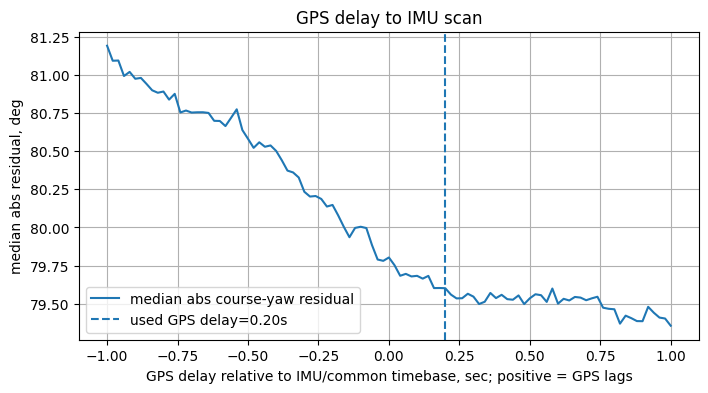

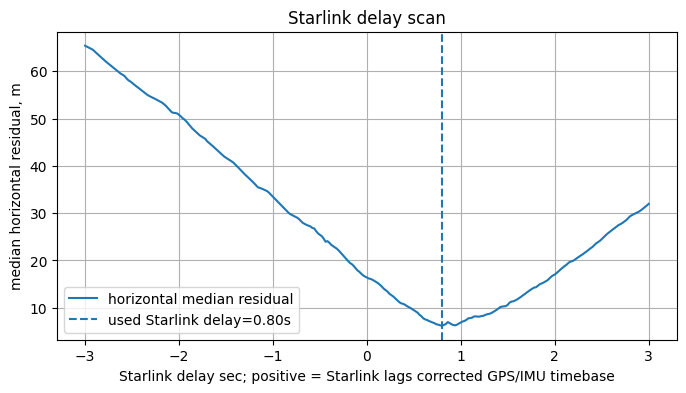

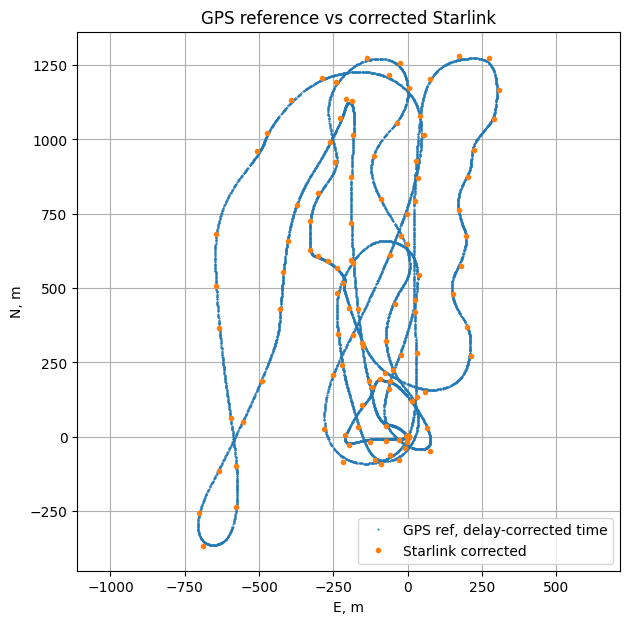

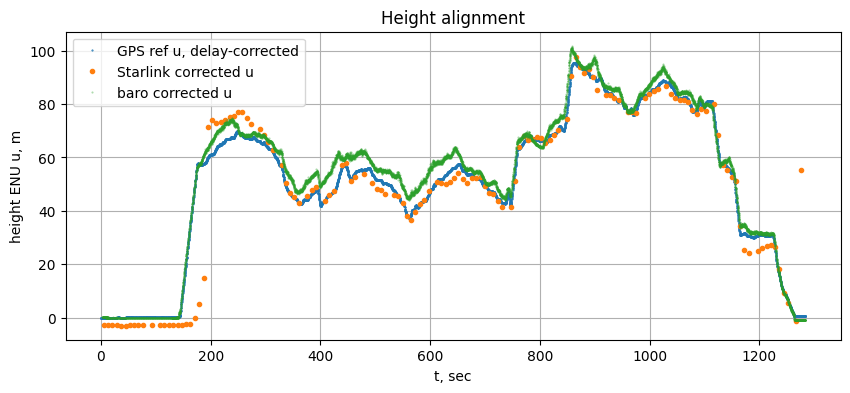

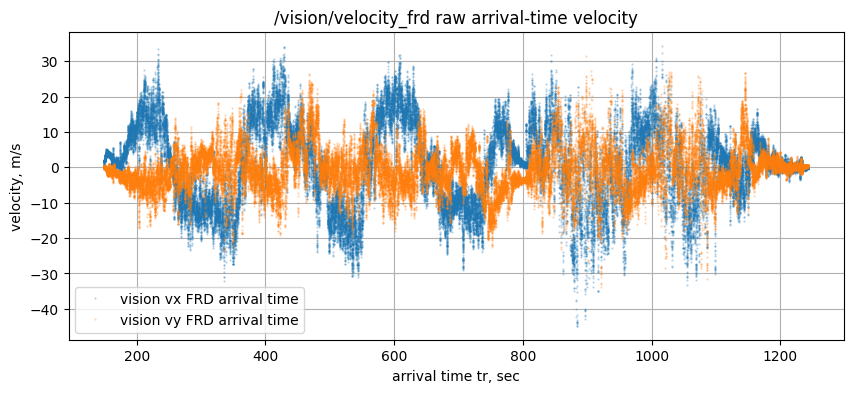

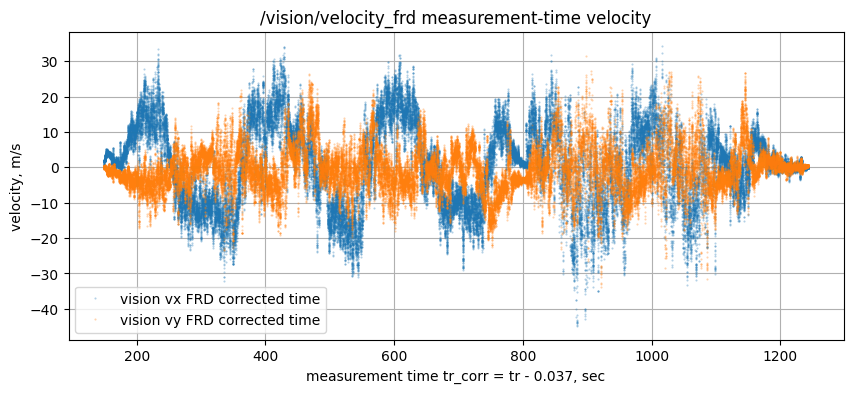

In [13]:

import numpy as np
import pandas as pd
import math
import json
import matplotlib.pyplot as plt
from typing import Any, cast

EXTRACT = EXTRACT_DIR
WORK = WORK_DIR
WORK.mkdir(parents=True, exist_ok=True)

# =============================================================================
# Основні параметри
# =============================================================================

STARTUP_CALIB_SEC = 180.0  #@param {type:"number"}

# Якщо GPS/IMU/Starlink/vision velocity не синхронізовані по header.stamp,
# використовуємо єдиний час запису rosbag.
# Варіанти:
#   "bag_t" - рекомендовано для несинхронізованих сенсорів
#   "t"     - тільки якщо всі header.stamp справді синхронізовані
TIME_MODE = "bag_t"  #@param ["bag_t", "t"]

# =============================================================================
# GPS delay відносно IMU/common timebase
# =============================================================================

OPTIMIZE_GPS_DELAY_TO_IMU = True   #@param {type:"boolean"}
GPS_DELAY_PRIOR_SEC = 0.20         #@param {type:"number"}
GPS_DELAY_MIN = -1.0               #@param {type:"number"}
GPS_DELAY_MAX =  1.0               #@param {type:"number"}
GPS_DELAY_STEP = 0.02              #@param {type:"number"}
GPS_IMU_SPEED_MIN = 2.0            #@param {type:"number"}
MIN_GPS_IMU_POINTS = 200           #@param {type:"integer"}
GPS_DELAY_USE_PRIOR_IF_UNRELIABLE = True

# positive GPS_DELAY_TO_IMU_SEC means:
#   GPS measurement lags IMU/common timebase,
#   real GPS measurement time = gps.t - GPS_DELAY_TO_IMU_SEC.

# =============================================================================
# Starlink delay відносно GPS, вже скоригованого до IMU/common timebase
# =============================================================================

DELAY_MIN = -3.0           #@param {type:"number"}
DELAY_MAX =  3.0           #@param {type:"number"}
DELAY_STEP = 0.02          #@param {type:"number"}
STARLINK_DELAY_PRIOR_SEC = 0.90  #@param {type:"number"}

SPEED_MIN_FOR_DELAY = 1.0
DELAY_CALIB_MAX_SEC = 900.0
MIN_MOVING_SL_POINTS = 8

# Offset краще оцінювати на рухомих Starlink-точках, де delay спостерігається.
# Варіанти: "moving", "startup", "all"
OFFSET_MODE = "moving"  #@param ["moving", "startup", "all"]

# Baro offset зазвичай можна оцінити на старті
BARO_CALIB_SEC = STARTUP_CALIB_SEC

# =============================================================================
# Optical-flow velocity delay
# =============================================================================

# /vision/velocity_frd записаний у MCAP з часом приходу t_flow.
# Реальний час вимірювання:
#   t_meas = t_flow - VISION_VEL_DELAY_SEC
#
# Якщо є підозра, що 37 ms замало, можна пробувати 0.045 або 0.050.
# Але якщо сильно міняєш це значення, краще також перерахувати velocity CSV,
# бо гірокомпенсація там теж використовувала FLOW_LAG_SEC.
VISION_VEL_DELAY_SEC = 0.037  #@param {type:"number"}

print("TIME_MODE:", TIME_MODE)
print("OPTIMIZE_GPS_DELAY_TO_IMU:", OPTIMIZE_GPS_DELAY_TO_IMU)
print("VISION_VEL_DELAY_SEC:", VISION_VEL_DELAY_SEC)

# =============================================================================
# Read CSV
# =============================================================================

gps_raw = pd.read_csv(EXTRACT / "device__gps__raw.csv")
sl_raw = pd.read_csv(EXTRACT / "device__starlink__raw.csv")
imu_raw = pd.read_csv(EXTRACT / "imu__data_raw.csv")
eul_raw = pd.read_csv(EXTRACT / "imu__euler.csv")
baro_raw = pd.read_csv(EXTRACT / "imu__pure_baro_alt.csv")

vel_path = EXTRACT / "vision__velocity_frd.csv"
HAS_VISION_VEL = vel_path.exists()

if HAS_VISION_VEL:
    vel_raw = pd.read_csv(vel_path)
    print("vision velocity loaded:", vel_path, "rows:", len(vel_raw))
else:
    vel_raw = None
    print("WARNING: vision velocity CSV not found:", vel_path)


def force_common_timebase(
    df: pd.DataFrame,
    name: str,
    time_mode: str = "bag_t",
) -> pd.DataFrame:
    """
    Робить df["t"] єдиним часовим масштабом для всіх сенсорів.

    Якщо TIME_MODE="bag_t":
      df["t"] = df["bag_t"]

    Старий timestamp зберігаємо в t_original.
    """
    d = df.copy()

    if "t" not in d.columns:
        raise RuntimeError(f"{name}: column 't' is missing")

    d["t_original"] = d["t"].astype(float)

    if time_mode == "bag_t":
        if "bag_t" not in d.columns:
            raise RuntimeError(
                f"{name}: column 'bag_t' is missing. Cannot use TIME_MODE='bag_t'."
            )
        d["t"] = d["bag_t"].astype(float)
        d["time_used"] = "bag_t"
    elif time_mode == "t":
        d["t"] = d["t"].astype(float)
        d["time_used"] = "t"
    else:
        raise ValueError("TIME_MODE must be 'bag_t' or 't'")

    d = cast(pd.DataFrame, d[np.isfinite(d["t"])]).copy()
    d = d.sort_values(by="t").reset_index(drop=True)

    before = len(d)
    d = d.drop_duplicates(subset=["t"], keep="first").reset_index(drop=True)
    after = len(d)

    if before != after:
        print(f"{name}: dropped duplicated timestamps: {before-after}")

    return d


gps = force_common_timebase(gps_raw, "gps", TIME_MODE)
sl = force_common_timebase(sl_raw, "starlink", TIME_MODE)
imu = force_common_timebase(imu_raw, "imu", TIME_MODE)
eul = force_common_timebase(eul_raw, "euler", TIME_MODE)
baro = force_common_timebase(baro_raw, "baro", TIME_MODE)

vel = pd.DataFrame()

if vel_raw is not None:
    vel = force_common_timebase(vel_raw, "vision_velocity", TIME_MODE)

    for c in ["vx", "vy", "vz"]:
        if c not in vel.columns:
            raise RuntimeError(f"vision_velocity: missing column {c}")

    vel = cast(pd.DataFrame, vel[
        np.isfinite(vel["t"])
        & np.isfinite(vel["vx"])
        & np.isfinite(vel["vy"])
        & np.isfinite(vel["vz"])
    ]).copy()

    vel = vel.sort_values(by="t").drop_duplicates(subset=["t"], keep="first").reset_index(drop=True)
    print("vision_velocity: valid points:", len(vel))

# =============================================================================
# Valid GPS / Starlink
# =============================================================================

def valid_navsat(df: pd.DataFrame, name: str) -> pd.DataFrame:
    d = df.copy()

    for c in ["lat", "lon", "alt"]:
        if c not in d.columns:
            raise RuntimeError(f"{name}: missing column {c}")

    d = cast(pd.DataFrame, d[
        np.isfinite(d["lat"])
        & np.isfinite(d["lon"])
        & np.isfinite(d["alt"])
    ]).copy()

    lat = cast(pd.Series, d["lat"])
    lon = cast(pd.Series, d["lon"])
    d = cast(pd.DataFrame, d[(lat.abs() > 1e-8) & (lon.abs() > 1e-8)]).copy()

    if "status" in d.columns:
        status = cast(pd.Series, d["status"])
        d = cast(pd.DataFrame, d[status >= 0]).copy()

    d = d.sort_values(by="t").drop_duplicates(subset=["t"], keep="first").reset_index(drop=True)

    if len(d) < 5:
        raise RuntimeError(f"{name}: too few valid points after filtering: {len(d)}")

    print(f"{name}: valid points:", len(d))
    return d


gps = valid_navsat(gps, "gps")
sl = valid_navsat(sl, "starlink")

if len(imu) < 10:
    raise RuntimeError("imu: too few points")
if len(eul) < 10:
    raise RuntimeError("euler: too few points")
if len(baro) < 10:
    raise RuntimeError("baro: too few points")

# =============================================================================
# Relative time before GPS latency correction
# =============================================================================

t0_candidates = [
    float(gps["t"].min()),
    float(sl["t"].min()),
    float(imu["t"].min()),
    float(eul["t"].min()),
    float(baro["t"].min()),
]

if HAS_VISION_VEL and len(vel):
    t0_candidates.append(float(vel["t"].min()))

t0 = min(t0_candidates)

for df_ in [gps, sl, imu, eul, baro]:
    df_["tr"] = df_["t"].astype(float) - t0

if HAS_VISION_VEL and len(vel):
    vel["tr"] = vel["t"].astype(float) - t0

    # corrected measurement time for optical-flow velocity
    vel["tr_corr"] = vel["tr"] - VISION_VEL_DELAY_SEC
    vel["t_corr"] = vel["t"] - VISION_VEL_DELAY_SEC

print("t0 epoch sec:", t0)
print("gps tr raw/common:", float(gps.tr.min()), float(gps.tr.max()))
print("starlink tr:", float(sl.tr.min()), float(sl.tr.max()))
print("imu tr:", float(imu.tr.min()), float(imu.tr.max()))
print("euler tr:", float(eul.tr.min()), float(eul.tr.max()))
print("baro tr:", float(baro.tr.min()), float(baro.tr.max()))

if HAS_VISION_VEL and len(vel):
    print("vision velocity tr arrival:", float(vel.tr.min()), float(vel.tr.max()))
    print("vision velocity tr corrected:", float(vel.tr_corr.min()), float(vel.tr_corr.max()))

# =============================================================================
# WGS84 <-> ENU
# =============================================================================

A = 6378137.0
F = 1.0 / 298.257223563
E2 = F * (2.0 - F)


def llh_to_ecef(lat, lon, h):
    lat = np.deg2rad(lat)
    lon = np.deg2rad(lon)
    s = np.sin(lat)
    c = np.cos(lat)
    N = A / np.sqrt(1.0 - E2 * s * s)
    x = (N + h) * c * np.cos(lon)
    y = (N + h) * c * np.sin(lon)
    z = (N * (1.0 - E2) + h) * s
    return np.stack([x, y, z], axis=-1)


def ecef_to_llh(x, y, z):
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)

    lon = np.arctan2(y, x)
    p = np.sqrt(x * x + y * y)
    lat = np.arctan2(z, p * (1.0 - E2))

    for _ in range(7):
        s = np.sin(lat)
        prime_vertical_radius = A / np.sqrt(1.0 - E2 * s * s)
        h = p / np.cos(lat) - prime_vertical_radius
        lat = np.arctan2(
            z,
            p * (1.0 - E2 * prime_vertical_radius / (prime_vertical_radius + h)),
        )

    s = np.sin(lat)
    prime_vertical_radius = A / np.sqrt(1.0 - E2 * s * s)
    h = p / np.cos(lat) - prime_vertical_radius

    return np.rad2deg(lat), np.rad2deg(lon), h


def R_ecef_to_enu(lat0, lon0):
    lat0 = math.radians(float(lat0))
    lon0 = math.radians(float(lon0))

    slat = math.sin(lat0)
    clat = math.cos(lat0)
    slon = math.sin(lon0)
    clon = math.cos(lon0)

    return np.array([
        [-slon,         clon,        0.0],
        [-slat * clon, -slat * slon, clat],
        [ clat * clon,  clat * slon, slat],
    ])


# Origin беремо зі звичайного GPS на початку запису до GPS-delay correction.
g0 = gps[gps["tr"] <= gps["tr"].min() + 5.0]

if len(g0) < 5:
    g0 = gps.head(50)

lat0 = float(cast(pd.Series, g0["lat"]).median())
lon0 = float(cast(pd.Series, g0["lon"]).median())
alt0 = float(cast(pd.Series, g0["alt"]).median())

R = R_ecef_to_enu(lat0, lon0)
ecef0 = llh_to_ecef(np.array([lat0]), np.array([lon0]), np.array([alt0]))[0]


def llh_to_enu(lat, lon, alt):
    ecef = llh_to_ecef(np.asarray(lat), np.asarray(lon), np.asarray(alt))
    return (ecef - ecef0) @ R.T


def enu_to_llh(e, n, u):
    enu = np.stack([np.asarray(e), np.asarray(n), np.asarray(u)], axis=-1)
    ecef = ecef0 + enu @ R
    return ecef_to_llh(ecef[..., 0], ecef[..., 1], ecef[..., 2])


gps[["e", "n", "u"]] = llh_to_enu(
    gps["lat"].values,
    gps["lon"].values,
    gps["alt"].values,
)

sl[["e", "n", "u"]] = llh_to_enu(
    sl["lat"].values,
    sl["lon"].values,
    sl["alt"].values,
)

print("Origin lat/lon/alt:", lat0, lon0, alt0)

# =============================================================================
# Estimate GPS delay relative to IMU/common timebase
# =============================================================================

def wrap_pi(a):
    return (a + np.pi) % (2.0 * np.pi) - np.pi


def circ_mean_angle(a):
    return float(np.angle(np.nanmean(np.exp(1j * a))))


def estimate_gps_delay_to_imu(
    gps_df: pd.DataFrame,
    eul_df: pd.DataFrame,
) -> dict[str, Any]:
    """
    Оцінює GPS delay відносно IMU за збігом GPS course і IMU yaw.

    positive tau:
      GPS timestamp/arrival запізнюється,
      real GPS measurement time = gps.t - tau.

    Метод коректний, якщо напрям руху приблизно відповідає yaw.
    """
    g = gps_df.copy().sort_values(by="tr").drop_duplicates(subset=["tr"], keep="first").reset_index(drop=True)
    ev = eul_df.copy().sort_values(by="tr").drop_duplicates(subset=["tr"], keep="first").reset_index(drop=True)

    if len(g) < 20 or len(ev) < 100:
        return dict(
            delay=float(GPS_DELAY_PRIOR_SEC),
            reliable=False,
            reason="too_few_samples",
            scan=pd.DataFrame(),
        )

    for c in ["roll", "pitch", "yaw"]:
        if c not in ev.columns:
            return dict(
                delay=float(GPS_DELAY_PRIOR_SEC),
                reliable=False,
                reason=f"missing_{c}",
                scan=pd.DataFrame(),
            )

    max_abs_angle = np.nanmax(np.abs(ev[["roll", "pitch", "yaw"]].values))
    scale = np.pi / 180.0 if max_abs_angle > 2.0 * np.pi + 0.1 else 1.0

    imu_t = ev["tr"].values.astype(float)
    imu_yaw = np.unwrap(ev["yaw"].values.astype(float) * scale)

    gt = g["tr"].values.astype(float)
    ge = g["e"].values.astype(float)
    gn = g["n"].values.astype(float)

    if not np.all(np.diff(gt) > 0.0):
        return dict(
            delay=float(GPS_DELAY_PRIOR_SEC),
            reliable=False,
            reason="gps_time_not_strictly_increasing",
            scan=pd.DataFrame(),
        )

    ve = np.gradient(ge, gt)
    vn = np.gradient(gn, gt)

    ve_s = cast(
        pd.Series,
        pd.Series(ve).rolling(21, center=True, min_periods=1).median(),
    ).to_numpy(dtype=float)
    vn_s = cast(
        pd.Series,
        pd.Series(vn).rolling(21, center=True, min_periods=1).median(),
    ).to_numpy(dtype=float)
    speed_s = np.sqrt(ve_s * ve_s + vn_s * vn_s)

    # GPS course у NED-heading логіці: 0 = North, +CW.
    gps_course_ned = np.unwrap(np.arctan2(ve_s, vn_s))

    rows: list[list[float | int]] = []

    for tau in np.arange(GPS_DELAY_MIN, GPS_DELAY_MAX + 1e-9, GPS_DELAY_STEP):
        tq = gt - tau

        ok = (
            (tq >= imu_t.min())
            & (tq <= imu_t.max())
            & np.isfinite(gps_course_ned)
            & np.isfinite(speed_s)
            & (speed_s > GPS_IMU_SPEED_MIN)
        )

        if ok.sum() < 20:
            continue

        yaw_i = np.interp(tq[ok], imu_t, imu_yaw)
        course_i = gps_course_ned[ok]

        diff = wrap_pi(course_i - yaw_i)

        # Прибираємо сталий yaw-bias між GPS course і IMU yaw.
        yaw_bias = circ_mean_angle(diff)
        res = wrap_pi(diff - yaw_bias)

        med_abs_deg = float(np.rad2deg(np.nanmedian(np.abs(res))))
        p90_abs_deg = float(np.rad2deg(np.nanpercentile(np.abs(res), 90)))

        rows.append([
            float(tau),
            med_abs_deg,
            p90_abs_deg,
            float(np.rad2deg(yaw_bias)),
            int(ok.sum()),
        ])

    scan = pd.DataFrame(
        rows,
        columns=pd.Index([
            "gps_delay_sec",
            "median_abs_course_yaw_error_deg",
            "p90_abs_course_yaw_error_deg",
            "yaw_bias_deg",
            "n_used",
        ]),
    )

    if len(scan) == 0:
        return dict(
            delay=float(GPS_DELAY_PRIOR_SEC),
            reliable=False,
            reason="empty_scan",
            scan=scan,
        )

    score_series = cast(pd.Series, scan["median_abs_course_yaw_error_deg"])
    best = cast(pd.Series, scan.loc[score_series.idxmin()])
    best_delay = float(best["gps_delay_sec"])

    at_left_edge = abs(best_delay - GPS_DELAY_MIN) <= GPS_DELAY_STEP * 1.5
    at_right_edge = abs(best_delay - GPS_DELAY_MAX) <= GPS_DELAY_STEP * 1.5
    too_few = int(best["n_used"]) < MIN_GPS_IMU_POINTS
    score_span = float(
        score_series.quantile(0.9)
        - score_series.min()
    )
    too_flat = score_span < 0.5

    unreliable = at_left_edge or at_right_edge or too_few or too_flat

    if unreliable and GPS_DELAY_USE_PRIOR_IF_UNRELIABLE:
        delay_used = float(GPS_DELAY_PRIOR_SEC)
    else:
        delay_used = best_delay

    reason = []

    if at_left_edge or at_right_edge:
        reason.append("edge")
    if too_few:
        reason.append("too_few")
    if too_flat:
        reason.append("too_flat")
    if not reason:
        reason.append("ok")

    return dict(
        delay=delay_used,
        raw_best_delay=best_delay,
        reliable=not unreliable,
        reason=",".join(reason),
        best=best,
        scan=scan,
    )


gps_imu_res: dict[str, Any]
gps_imu_scan: pd.DataFrame

if OPTIMIZE_GPS_DELAY_TO_IMU:
    gps_imu_res = estimate_gps_delay_to_imu(gps, eul)
    gps_delay_to_imu_sec = float(gps_imu_res["delay"])
    gps_imu_scan = gps_imu_res["scan"]

    print("GPS delay relative to IMU/common timebase:")
    print("  used:", gps_delay_to_imu_sec)
    print("  reliable:", gps_imu_res["reliable"])
    print("  reason:", gps_imu_res["reason"])

    if "best" in gps_imu_res:
        print("  raw best:")
        print(gps_imu_res["best"])
else:
    gps_delay_to_imu_sec = float(GPS_DELAY_PRIOR_SEC)
    gps_imu_scan = pd.DataFrame()
    gps_imu_res = dict(
        delay=gps_delay_to_imu_sec,
        reliable=False,
        reason="optimization_disabled",
        scan=gps_imu_scan,
    )
    print("GPS delay optimization disabled. Using prior/fixed:", gps_delay_to_imu_sec)

# Apply GPS delay correction.
gps["t_before_gps_imu_delay_correction"] = gps["t"].copy()
gps["tr_before_gps_imu_delay_correction"] = gps["tr"].copy()
gps["t"] = gps["t"].astype(float) - gps_delay_to_imu_sec
gps["tr"] = gps["t"] - t0
gps = gps.sort_values(by="t").drop_duplicates(subset=["t"], keep="first").reset_index(drop=True)

print("Applied GPS_DELAY_TO_IMU_SEC:", gps_delay_to_imu_sec)
print("corrected gps tr:", float(gps.tr.min()), float(gps.tr.max()))

# =============================================================================
# Prepare reference arrays after GPS delay correction
# =============================================================================

ref_t = gps["tr"].values.astype(float)
ref = gps[["e", "n", "u"]].values.astype(float)

slt = sl["tr"].values.astype(float)
slp = sl[["e", "n", "u"]].values.astype(float)

if not np.all(np.diff(ref_t) > 0.0):
    raise RuntimeError("GPS ref_t is not strictly increasing after delay correction")


def interp_xyz(tq):
    tq = np.asarray(tq, dtype=float)

    return np.vstack([
        np.interp(tq, ref_t, ref[:, 0]),
        np.interp(tq, ref_t, ref[:, 1]),
        np.interp(tq, ref_t, ref[:, 2]),
    ]).T


def interp_xy(tq):
    tq = np.asarray(tq, dtype=float)

    return np.vstack([
        np.interp(tq, ref_t, ref[:, 0]),
        np.interp(tq, ref_t, ref[:, 1]),
    ]).T


# GPS speed for Starlink delay moving-segment selection
ve = np.gradient(ref[:, 0], ref_t)
vn = np.gradient(ref[:, 1], ref_t)
gps_speed_h = np.sqrt(ve * ve + vn * vn)

gps_speed_h_smooth = cast(
    pd.Series,
    pd.Series(gps_speed_h)
    .rolling(51, center=True, min_periods=1)
    .median(),
).to_numpy(dtype=float)


def robust_score_xy(res_xy):
    r = np.sqrt(np.sum(res_xy * res_xy, axis=1))
    return float(np.nanmedian(r))

# =============================================================================
# Robust Starlink delay estimation against GPS already corrected to IMU timebase
# =============================================================================

DELAY_PRIOR = STARLINK_DELAY_PRIOR_SEC

delay_cal = (slt >= 0.0) & (slt <= min(DELAY_CALIB_MAX_SEC, float(slt.max())))

rows: list[list[float | int]] = []

for tau in np.arange(DELAY_MIN, DELAY_MAX + 1e-9, DELAY_STEP):
    # tau > 0: Starlink запізнюється,
    # real measurement time = sl.t - tau.
    tq = slt[delay_cal] - tau

    ok = (tq >= ref_t.min()) & (tq <= ref_t.max())

    if ok.sum() < 3:
        continue

    speed_q = np.interp(tq, ref_t, gps_speed_h_smooth)
    ok = ok & (speed_q > SPEED_MIN_FOR_DELAY)

    if ok.sum() < 3:
        continue

    sl_xy = slp[delay_cal][ok, :2]
    gps_xy = interp_xy(tq[ok])

    diff_xy = sl_xy - gps_xy

    # Для кожного tau прибираємо постійний XY offset.
    off_xy = np.nanmedian(diff_xy, axis=0)
    res_xy = diff_xy - off_xy

    score_h = robust_score_xy(res_xy)
    rmse_h = float(np.sqrt(np.mean(np.sum(res_xy * res_xy, axis=1))))

    rows.append([
        float(tau),
        score_h,
        rmse_h,
        int(ok.sum()),
        float(off_xy[0]),
        float(off_xy[1]),
    ])

scan = pd.DataFrame(
    rows,
    columns=pd.Index([
        "delay_sec",
        "score_h_median",
        "rmse_h",
        "n_used",
        "off_e_tmp",
        "off_n_tmp",
    ]),
)

if len(scan) == 0:
    print("Starlink delay is not observable: no moving Starlink points.")
    print("Using STARLINK_DELAY_PRIOR_SEC:", DELAY_PRIOR)
    delay = float(DELAY_PRIOR)
    delay_reliable = False
else:
    score_series = cast(pd.Series, scan["score_h_median"])
    best = cast(pd.Series, scan.loc[score_series.idxmin()])
    best_delay = float(best["delay_sec"])

    at_left_edge = abs(best_delay - DELAY_MIN) <= DELAY_STEP * 1.5
    at_right_edge = abs(best_delay - DELAY_MAX) <= DELAY_STEP * 1.5
    too_few = int(best["n_used"]) < MIN_MOVING_SL_POINTS
    score_span = float(score_series.quantile(0.9) - score_series.min())
    too_flat = score_span < 1.0

    if at_left_edge or at_right_edge or too_few or too_flat:
        print("Starlink delay estimate is unreliable.")
        print(
            "Reason:",
            "edge" if (at_left_edge or at_right_edge) else "",
            "too_few" if too_few else "",
            "too_flat" if too_flat else "",
        )
        print("Raw best Starlink delay:", best_delay)
        print("Using STARLINK_DELAY_PRIOR_SEC:", DELAY_PRIOR)
        delay = float(DELAY_PRIOR)
        delay_reliable = False
    else:
        delay = best_delay
        delay_reliable = True

    print("Starlink delay scan best raw:")
    print(best)

print("Final Starlink delay sec, positive=Starlink lag to IMU/common timebase:", delay)
print("Starlink delay reliable:", delay_reliable)
print("Raw Starlink delay relative to uncorrected GPS timebase, approx:", delay - gps_delay_to_imu_sec)

# =============================================================================
# Offset ENU estimation
# =============================================================================

def get_offset_mask(mode):
    if mode == "startup":
        m = (slt >= 0.0) & (slt <= STARTUP_CALIB_SEC)
        note = "startup"
    elif mode == "moving":
        tq_tmp = slt - delay
        gps_speed_at_sl = np.interp(
            np.clip(tq_tmp, ref_t.min(), ref_t.max()),
            ref_t,
            gps_speed_h_smooth,
        )
        m = (
            (slt >= 0.0)
            & (slt <= min(DELAY_CALIB_MAX_SEC, float(slt.max())))
            & (gps_speed_at_sl > SPEED_MIN_FOR_DELAY)
        )
        note = "moving"

        if m.sum() < 5:
            m = np.ones_like(slt, dtype=bool)
            note = "fallback_all"
    elif mode == "all":
        m = np.ones_like(slt, dtype=bool)
        note = "all"
    else:
        raise ValueError("OFFSET_MODE must be 'moving', 'startup', or 'all'")

    return m, note


off_mask, offset_note = get_offset_mask(OFFSET_MODE)

tq_off = slt[off_mask] - delay
ok_off = (tq_off >= ref_t.min()) & (tq_off <= ref_t.max())

if ok_off.sum() < 5:
    raise RuntimeError("Not enough Starlink points to estimate ENU offset.")

diff3 = slp[off_mask][ok_off] - interp_xyz(tq_off[ok_off])

off = np.nanmedian(diff3, axis=0)

res3 = diff3 - off
rmse3 = float(np.sqrt(np.mean(np.sum(res3 * res3, axis=1))))
rmseh = float(np.sqrt(np.mean(np.sum(res3[:, :2] * res3[:, :2], axis=1))))
rmsez = float(np.sqrt(np.mean(res3[:, 2] ** 2)))

print("Offset mode used:", offset_note)
print("Final ENU offset Starlink-GPS, m:", off)
print("Offset fit rmse3/rmseh/rmsez:", rmse3, rmseh, rmsez)

# =============================================================================
# Corrected Starlink
# =============================================================================

slc = sl.copy()
slc["tr_corr"] = slc["tr"] - delay
slc["t_corr"] = t0 + slc["tr_corr"]
slc[["e_corr", "n_corr", "u_corr"]] = slc[["e", "n", "u"]].values.astype(float) - off

# =============================================================================
# Baro Z aligned to corrected GPS height
# =============================================================================

bmask = (baro["tr"] >= 0.0) & (baro["tr"] <= BARO_CALIB_SEC)

if bmask.sum() <= 10:
    bmask = (baro["tr"] >= ref_t.min()) & (baro["tr"] <= ref_t.max())

if bmask.sum() > 10:
    baro_ref_u = np.interp(
        baro.loc[bmask, "tr"].values.astype(float),
        ref_t,
        ref[:, 2],
    )
    baro_offset = float(
        np.nanmedian(
            baro_ref_u - baro.loc[bmask, "alt"].values.astype(float)
        )
    )
else:
    baro_offset = 0.0

baro["u_corr"] = baro["alt"].astype(float) + baro_offset

print("baro_offset:", baro_offset)

# =============================================================================
# Initial velocity from corrected GPS first 20 sec
# =============================================================================

vm = (gps["tr"] >= 0.0) & (gps["tr"] <= min(20.0, STARTUP_CALIB_SEC))

v0 = np.zeros(3, dtype=float)

if vm.sum() >= 5:
    for i, c in enumerate(["e", "n", "u"]):
        v0[i] = np.polyfit(
            gps.loc[vm, "tr"].values.astype(float),
            gps.loc[vm, c].values.astype(float),
            1,
        )[0]

print("v0 ENU m/s:", v0)

# =============================================================================
# Save calibration and normalized CSVs
# =============================================================================

calib = dict(
    time_mode=TIME_MODE,
    time_note=(
        "All sensor timestamps were forced to bag_t because GPS/IMU/Starlink/Vision velocity are not assumed " +
        "to be synchronized by header.stamp."
        if TIME_MODE == "bag_t"
        else "Using original t/header timestamps. Use only if all sensors are synchronized."
    ),
    t0_epoch_sec=float(t0),
    lat0=float(lat0),
    lon0=float(lon0),
    alt0=float(alt0),

    gps_delay_to_imu_sec=float(gps_delay_to_imu_sec),
    gps_delay_reliable=bool(gps_imu_res.get("reliable", False)),
    gps_delay_reason=str(gps_imu_res.get("reason", "unknown")),
    gps_delay_prior_sec=float(GPS_DELAY_PRIOR_SEC),
    gps_delay_note=(
        "Positive means GPS measurement lags IMU/common timebase. "
        "GPS time was corrected as gps.t = gps.t - gps_delay_to_imu_sec before Starlink calibration."
    ),

    starlink_delay_to_corrected_gps_sec=float(delay),
    starlink_delay_to_imu_sec=float(delay),
    starlink_delay_relative_to_uncorrected_gps_sec=float(delay - gps_delay_to_imu_sec),
    starlink_delay_reliable=bool(delay_reliable),
    starlink_delay_prior_sec=float(DELAY_PRIOR),
    starlink_delay_note=(
        "GPS was shifted to IMU/common timebase before estimating Starlink delay. "
        "Therefore the applied Starlink correction is sl.t - starlink_delay_to_corrected_gps_sec. "
        "Do not add gps_delay_to_imu_sec again in processing."
    ),

    vision_velocity_available=bool(HAS_VISION_VEL and len(vel)),
    vision_velocity_delay_sec=float(VISION_VEL_DELAY_SEC),
    vision_velocity_delay_note=(
        "Positive means /vision/velocity_frd lags IMU/common timebase. "
        "The topic timestamp is arrival/publication time t_flow. "
        "Use measurement time t_meas = t - vision_velocity_delay_sec. "
        "If this value is changed significantly, recompute optical-flow velocity CSV because "
        "gyro compensation was also computed using FLOW_LAG_SEC."
    ),

    offset_mode=offset_note,
    offset_enu_starlink_minus_gps_m=off.tolist(),
    offset_fit_rmse3_m=rmse3,
    offset_fit_rmseh_m=rmseh,
    offset_fit_rmsez_m=rmsez,
    baro_offset_m=float(baro_offset),
    v0_enu_mps=v0.tolist(),
    startup_calib_sec=float(STARTUP_CALIB_SEC),
    delay_estimation_note=(
        "GPS delay to IMU/common timebase was estimated first and applied to GPS timestamps. "
        "Then Starlink delay was estimated against corrected GPS on moving XY segments. "
        "Vision velocity delay is stored separately and should be applied as t_meas = t - vision_velocity_delay_sec."
    ),
)

(WORK / "calibration.json").write_text(json.dumps(calib, indent=2))

# Основні файли для наступних комірок
gps.to_csv(WORK / "gps_ref_enu.csv", index=False)

# RAW Starlink ENU is the realistic live input:
# raw arrival tr + raw ENU.
# The navigation cell applies Starlink delay and ENU offset internally.
sl.to_csv(WORK / "starlink_raw_enu.csv", index=False)
slc.to_csv(WORK / "starlink_corrected_enu.csv", index=False)

baro.to_csv(WORK / "baro_corrected.csv", index=False)
scan.to_csv(WORK / "delay_scan.csv", index=False)
gps_imu_scan.to_csv(WORK / "gps_imu_delay_scan.csv", index=False)

# ВАЖЛИВО для комірки 6:
# ці файли вже мають t=bag_t і tr=t-t0
imu.to_csv(WORK / "imu_timebase.csv", index=False)
eul.to_csv(WORK / "euler_timebase.csv", index=False)

if HAS_VISION_VEL and len(vel):
    # Реалістичний live input:
    # arrival time tr + FRD/body velocity.
    vel.to_csv(WORK / "vision_velocity_raw_frd.csv", index=False)

    # Зручний файл, де tr/t вже зсунуті на measurement time.
    # Для online replay краще використовувати raw + delay.
    vel_corr = vel.copy()
    vel_corr["tr_arrival"] = vel_corr["tr"]
    vel_corr["t_arrival"] = vel_corr["t"]
    vel_corr["tr"] = vel_corr["tr_corr"]
    vel_corr["t"] = vel_corr["t_corr"]
    vel_corr.to_csv(WORK / "vision_velocity_corrected_frd.csv", index=False)

print("Saved:")
for fn in [
    "calibration.json",
    "gps_ref_enu.csv",
    "starlink_raw_enu.csv",
    "starlink_corrected_enu.csv",
    "baro_corrected.csv",
    "imu_timebase.csv",
    "euler_timebase.csv",
    "delay_scan.csv",
    "gps_imu_delay_scan.csv",
    "vision_velocity_raw_frd.csv",
    "vision_velocity_corrected_frd.csv",
]:
    p = WORK / fn

    if p.exists():
        print(" ", p)

# =============================================================================
# Plots
# =============================================================================

if len(gps_imu_scan):
    plt.figure(figsize=(8, 4))
    plt.plot(
        gps_imu_scan["gps_delay_sec"],
        gps_imu_scan["median_abs_course_yaw_error_deg"],
        label="median abs course-yaw residual",
    )
    plt.axvline(
        gps_delay_to_imu_sec,
        ls="--",
        label=f"used GPS delay={gps_delay_to_imu_sec:.2f}s",
    )
    plt.grid()
    plt.xlabel("GPS delay relative to IMU/common timebase, sec; positive = GPS lags")
    plt.ylabel("median abs residual, deg")
    plt.legend()
    plt.title("GPS delay to IMU scan")
    plt.show()

plt.figure(figsize=(8, 4))

if len(scan):
    plt.plot(scan["delay_sec"], scan["score_h_median"], label="horizontal median residual")
    plt.axvline(delay, ls="--", label=f"used Starlink delay={delay:.2f}s")
    plt.xlabel("Starlink delay sec; positive = Starlink lags corrected GPS/IMU timebase")
    plt.ylabel("median horizontal residual, m")
    plt.grid()
    plt.legend()
    plt.title("Starlink delay scan")
else:
    plt.text(0.5, 0.5, "Starlink delay scan is empty", ha="center", va="center")
    plt.axis("off")

plt.show()

plt.figure(figsize=(7, 7))
plt.plot(gps["e"], gps["n"], ".", ms=1, label="GPS ref, delay-corrected time")
plt.plot(slc["e_corr"], slc["n_corr"], "o", ms=3, label="Starlink corrected")
plt.axis("equal")
plt.grid()
plt.legend()
plt.xlabel("E, m")
plt.ylabel("N, m")
plt.title("GPS reference vs corrected Starlink")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(gps["tr"], gps["u"], ".", ms=1, label="GPS ref u, delay-corrected")
plt.plot(slc["tr_corr"], slc["u_corr"], "o", ms=3, label="Starlink corrected u")

if len(baro):
    plt.plot(
        baro["tr"],
        baro["u_corr"],
        ".",
        ms=1,
        alpha=0.4,
        label="baro corrected u",
    )

plt.grid()
plt.xlabel("t, sec")
plt.ylabel("height ENU u, m")
plt.legend()
plt.title("Height alignment")
plt.show()

if HAS_VISION_VEL and len(vel):
    plt.figure(figsize=(10, 4))
    plt.plot(
        vel["tr"],
        vel["vx"],
        ".",
        ms=1,
        alpha=0.35,
        label="vision vx FRD arrival time",
    )
    plt.plot(
        vel["tr"],
        vel["vy"],
        ".",
        ms=1,
        alpha=0.35,
        label="vision vy FRD arrival time",
    )
    plt.grid()
    plt.xlabel("arrival time tr, sec")
    plt.ylabel("velocity, m/s")
    plt.legend()
    plt.title("/vision/velocity_frd raw arrival-time velocity")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(
        vel["tr_corr"],
        vel["vx"],
        ".",
        ms=1,
        alpha=0.35,
        label="vision vx FRD corrected time",
    )
    plt.plot(
        vel["tr_corr"],
        vel["vy"],
        ".",
        ms=1,
        alpha=0.35,
        label="vision vy FRD corrected time",
    )
    plt.grid()
    plt.xlabel(f"measurement time tr_corr = tr - {VISION_VEL_DELAY_SEC:.3f}, sec")
    plt.ylabel("velocity, m/s")
    plt.legend()
    plt.title("/vision/velocity_frd measurement-time velocity")
    plt.show()
else:
    print("No /vision/velocity_frd data available for plots.")


## 3. GTSAM Incremental Fixed-Lag Smoother

Original cell 37. Це основний алгоритм: strict-causal граф 5 Hz з IMU,
рідкісним Starlink/GPS, barometer/AHRS та м'якою опорою на optical-flow
velocity. The numerical algorithm is unchanged; local paths and targeted pandas/GTSAM type narrowing were added.


Loaded vision velocity: /home/fedor/project_cv_runtime/artifacts/fusion_v1/work/vision_velocity_raw_frd.csv rows: 59859
Vision velocity available: True
Vision velocity points: 59859
Vision arrival tr: 148.77892065048218 1243.43603181839
Vision corrected tr_corr: 148.74192065048217 1243.39903181839
BARO align:
  p0[U]      = 5.979999968170551
  baro_u0    = 4.184589630259276
  offset     = 1.7954103379112754

========== INIT ==========
base_t_start=5.260, base_t_end=1276.743, duration=1271.5s
motion_start=147.89195251464844, motion_source_used=gps1
active t_start=146.892, t_end=1276.743, nodes=5650
GRAPH_HZ=5.0, OUTPUT_HZ=5.0, FIXED_LAG_SEC=20.0
Backend: IncrementalFixedLagSmoother owns marginalization; no manual anchors/rebuilds
p0=[-0.17406697  0.60058822  5.97999997], source=gps1_past_sample
v0=[-0.04882771  0.2139322   1.99082555], norm=2.003 m/s, source=gps1_two_point
Starlink points after trim=126, GPS1 points after trim=8706
Vision velocity points after trim=59859
USE_BARO_Z=True

,idx,tr,e,n,u,ve,vn,vu,source,t
0,0,146.891953,0.293586,2.006418,6.088372,2.181625,0.516123,1.651744,fixed_lag_final,1.780851e+09
1,1,147.091953,0.758669,2.081897,6.405178,2.462243,0.468731,1.562159,fixed_lag_final,1.780851e+09
2,2,147.291953,1.272042,2.170937,6.720801,2.660299,0.145452,1.571537,fixed_lag_final,1.780851e+09
3,3,147.491953,1.786560,2.158981,7.041644,2.536372,-0.052812,1.704986,fixed_lag_final,1.780851e+09
4,4,147.691953,2.303739,2.159741,7.392829,2.561270,0.005484,1.778989,fixed_lag_final,1.780851e+09


,idx,tr,e,n,u,ve,vn,vu,source,t
5645,5645,1275.891953,10.933289,-21.917986,0.783641,1.960554,-3.913202,-0.004466,tail_final,1.780852e+09
5646,5646,1276.091953,11.328514,-22.707121,0.782763,1.991749,-3.978968,-0.003769,tail_final,1.780852e+09
5647,5647,1276.291953,11.729915,-23.509649,0.782109,2.022527,-4.045342,-0.002802,tail_final,1.780852e+09
5648,5648,1276.491953,12.137545,-24.325741,0.781621,2.053637,-4.114567,-0.002280,tail_final,1.780852e+09
5649,5649,1276.691953,12.551389,-25.155566,0.781323,2.084245,-4.183868,-0.000533,tail_final,1.780852e+09


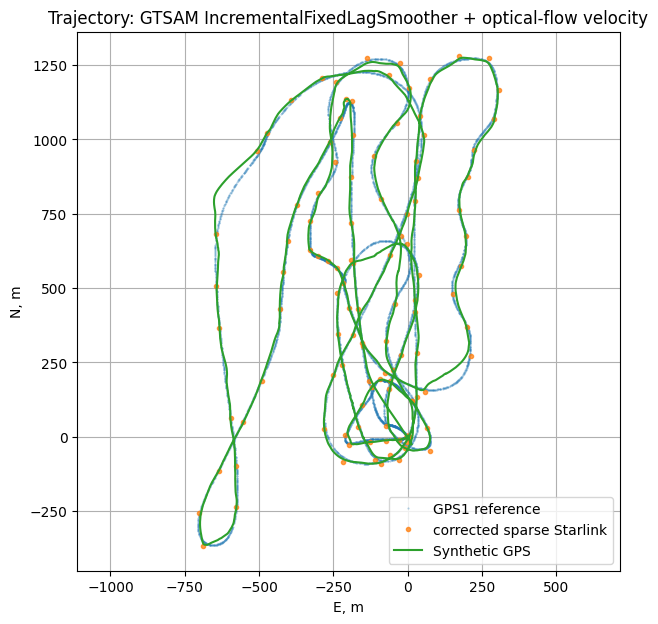

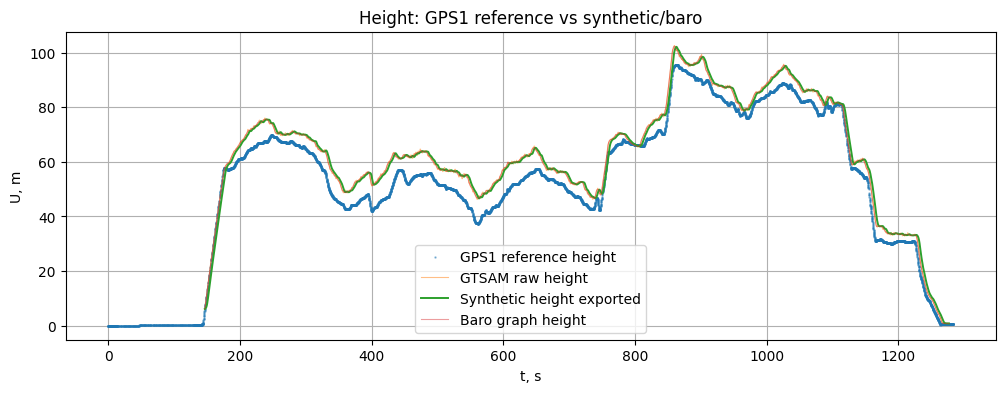

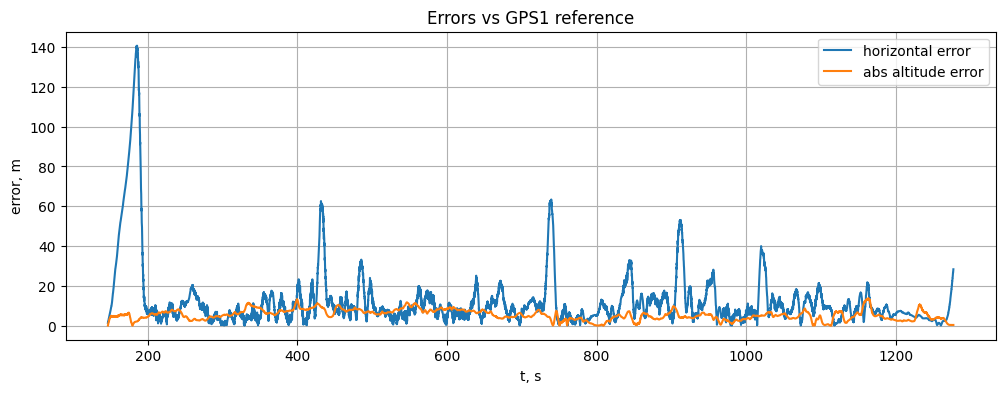

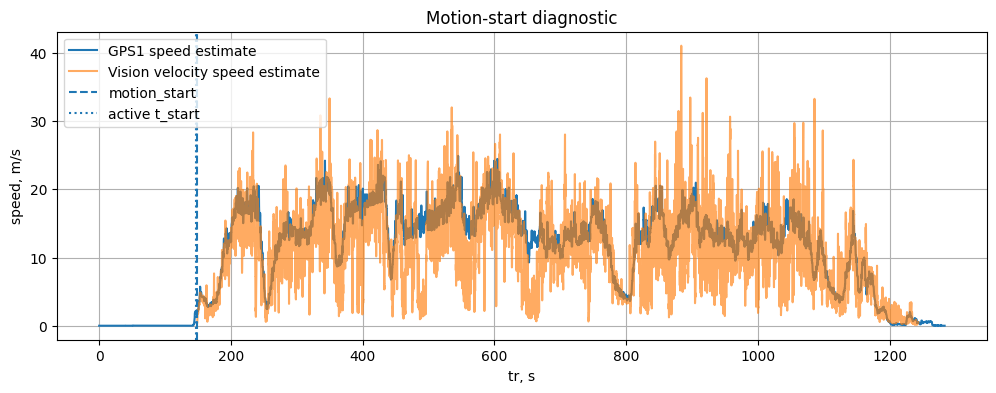

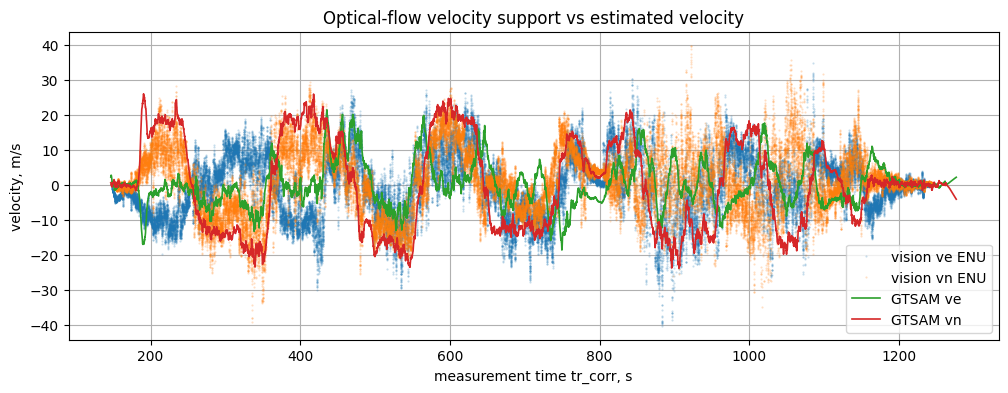

In [14]:

import gc
import json
import math

import numpy as np
import numpy.typing as npt
import pandas as pd
import matplotlib.pyplot as plt
from typing import Any, cast

import gtsam
from gtsam.symbol_shorthand import X, V, B  # pyright: ignore[reportAttributeAccessIssue]
gtsam_api: Any = gtsam


# =============================================================================
# Paths / load data
# =============================================================================
FUSION_WORK_PATH = WORK_DIR
FUSION_RESULTS_PATH = FUSION_OUTPUT_DIR
FUSION_RESULTS_PATH.mkdir(parents=True, exist_ok=True)

calib = cast(dict[str, Any], json.loads((FUSION_WORK_PATH / "calibration.json").read_text()))

imu = pd.read_csv(FUSION_WORK_PATH / "imu_timebase.csv").sort_values(by="tr").drop_duplicates(subset=["tr"]).reset_index(drop=True)
eul = pd.read_csv(FUSION_WORK_PATH / "euler_timebase.csv").sort_values(by="tr").drop_duplicates(subset=["tr"]).reset_index(drop=True)
slc = pd.read_csv(FUSION_WORK_PATH / "starlink_corrected_enu.csv").sort_values(by="tr").drop_duplicates(subset=["tr"]).reset_index(drop=True)
baro = pd.read_csv(FUSION_WORK_PATH / "baro_corrected.csv").sort_values(by="tr").drop_duplicates(subset=["tr"]).reset_index(drop=True)
gps_ref = pd.read_csv(FUSION_WORK_PATH / "gps_ref_enu.csv").sort_values(by="tr").drop_duplicates(subset=["tr"]).reset_index(drop=True)

VISION_VEL_PATH = FUSION_WORK_PATH / "vision_velocity_raw_frd.csv"
HAS_VISION_VEL_FILE = VISION_VEL_PATH.exists()

if HAS_VISION_VEL_FILE:
    vision_vel_raw = pd.read_csv(VISION_VEL_PATH).sort_values(by="tr").drop_duplicates(subset=["tr"]).reset_index(drop=True)
    print("Loaded vision velocity:", VISION_VEL_PATH, "rows:", len(vision_vel_raw))
else:
    vision_vel_raw = pd.DataFrame()
    print("WARNING: vision velocity file not found:", VISION_VEL_PATH)


# =============================================================================
# Main runtime parameters
# =============================================================================
GRAPH_HZ = 5.0
OUTPUT_HZ = GRAPH_HZ
FIXED_LAG_SEC = 20.0

SPARSE_TARGET_MAX_DT_SEC = 1.05 / GRAPH_HZ + 0.02
VISION_TARGET_MAX_DT_SEC = 1.05 / GRAPH_HZ + 0.02

MAX_ACTIVE_NODES = None
PRUNE_BATCH_NODES = None

FUSE_STARLINK_SPARSE_GPS = True
FUSE_REF_GPS1 = False
USE_AHRS_ORIENTATION_PRIOR = True
USE_BARO_Z = True

AHRS_FACTOR_HZ = 1.0
BARO_FACTOR_HZ = 2.0
ESTIMATE_EVERY_NODES = 5
PLOT_DECIMATE = 1

STRICT_CAUSAL_NO_FUTURE_PEEK = True
ENABLE_OFFLINE_DIAGNOSTICS = True

# =============================================================================
# Optical-flow velocity support
# =============================================================================

USE_VISION_VELOCITY_FACTOR = True
FUSION_VISION_VEL_DELAY_SEC = float(calib.get("vision_velocity_delay_sec", 0.037))

# Flow velocity is noisy, тому це має бути опора, а не жорсткий GPS-подібний constraint.
# Починай з 6..10 м/с. Якщо траєкторію "тягне" потік — збільшити.
VISION_VEL_XY_SIGMA_MPS = 7.0
VISION_VEL_Z_SIGMA_MPS = 1e6

# Відсікаємо зовсім нереальні flow-швидкості до усереднення.
MAX_VISION_VEL_FRD_MPS = 70.0
MAX_VISION_VEL_ENU_MPS = 70.0

# Скільки flow-семплів мінімум треба для одного усередненого velocity factor.
VISION_VEL_MIN_SAMPLES_PER_FACTOR = 3

# Для кожного graph-node накопичуються всі flow-семпли, які по corrected time
# припадають на цей вузол. Потім додається один усереднений factor.
VISION_VEL_AGGREGATION = "robust_mean"  # "mean", "median", "robust_mean"

# Щоб не додавати неповний bin, чекаємо поки пройде приблизно один node_dt + delay.
VISION_BIN_FLUSH_MARGIN_SEC = 0.02

USE_ROBUST_VISION_VEL_NOISE = True
VISION_VEL_ROBUST_HUBER_K = 2.5

# =============================================================================
# Sparse Starlink velocity pseudo-measurements from sparse positions
# =============================================================================

USE_STARLINK_VELOCITY_FACTOR = False
STARLINK_VEL_XY_SIGMA_MPS = 8.0
STARLINK_VEL_Z_SIGMA_MPS = 1e6
MAX_SPARSE_VEL_MPS = 35.0

# =============================================================================
# Motion-start / initialization
# =============================================================================

TRIM_START_BY_MOTION = True
START_WHEN_SPEED_GT_MPS = 1.0
START_SPEED_HOLD_SEC = 3.0
START_EXTRA_MARGIN_SEC = 1.0
START_SPEED_SOURCE = "auto"        # "gps1", "starlink", "vision", "auto"

INIT_POSITION_SOURCE = "gps1"      # "gps1", "starlink", "auto"
INIT_VELOCITY_SOURCE = "auto"      # "gps1", "starlink", "vision", "auto"
INIT_VELOCITY_WINDOW_SEC = 15.0
INIT_VELOCITY_MIN_SPEED_MPS = 0.5

CLAMP_INITIAL_VU_IF_LOW_ALT = True
LOW_ALT_FOR_VU_CLAMP_M = 5.0

TRIM_MEASUREMENTS_BEFORE_START = True

# =============================================================================
# Debug short run
# =============================================================================

DEBUG_SHORT_RUN = False
DEBUG_START_OFFSET_SEC = 0.0
DEBUG_DURATION_SEC = 60.0
DEBUG_MAX_NODES = 300

# Optional Starlink delay override.
USE_STARLINK_DELAY_OVERRIDE = False
STARLINK_DELAY_OVERRIDE_SEC = float(calib.get("starlink_delay_to_imu_sec", 0.8))

# =============================================================================
# Output height smoothing
# =============================================================================

SMOOTH_HEIGHT_OUTPUT = True
USE_SMOOTH_HEIGHT_FOR_EXPORT = True
HEIGHT_SMOOTH_MEDIAN_WIN = 11
HEIGHT_SMOOTH_MEAN_WIN = 11

BARO_USE_CAUSAL_IIR_LPF = True
BARO_LPF_TAU_SEC = 0.8
HEIGHT_USE_CAUSAL_IIR_LPF = True
HEIGHT_LPF_TAU_SEC = 0.8


def causal_iir_lpf_by_time(t_arr, y_arr, tau_sec, y0=None):
    """Causal first-order IIR LPF by timestamps. Uses only current and past samples."""
    t_arr = np.asarray(t_arr, dtype=float)
    y_arr = np.asarray(y_arr, dtype=float)
    out = np.full_like(y_arr, np.nan, dtype=float)

    if len(y_arr) == 0:
        return out

    tau = max(float(tau_sec), 1e-6)

    finite = np.flatnonzero(np.isfinite(y_arr))
    if len(finite) == 0:
        return out

    i0 = int(finite[0])
    out[:i0] = y_arr[i0] if y0 is None else float(y0)
    out[i0] = y_arr[i0] if y0 is None else float(y0)

    last = float(out[i0])
    last_t = float(t_arr[i0]) if np.isfinite(t_arr[i0]) else 0.0

    for i in range(i0 + 1, len(y_arr)):
        yi = y_arr[i]
        ti = float(t_arr[i]) if np.isfinite(t_arr[i]) else last_t

        dt = max(0.0, ti - last_t)
        alpha = 1.0 - math.exp(-dt / tau) if dt > 0.0 else 0.0

        if np.isfinite(yi):
            last = last + alpha * (float(yi) - last)

        out[i] = last
        last_t = ti

    return out


# =============================================================================
# Noise / model parameters
# =============================================================================

GRAVITY = 9.80665

ACCEL_NOISE_SIGMA = 1.5
GYRO_NOISE_SIGMA = 0.05
INTEGRATION_SIGMA = 0.01

ACCEL_BIAS_PRIOR_SIGMA = 0.05
GYRO_BIAS_PRIOR_SIGMA = 0.005
ACCEL_BIAS_RW_SIGMA = 0.05
GYRO_BIAS_RW_SIGMA = 0.002

STARLINK_XY_SIGMA_M = 2.5
STARLINK_Z_SIGMA_M = 100.0
USE_ROBUST_STARLINK_POSITION_NOISE = False
STARLINK_ROBUST_HUBER_K = 5.0

REF_GPS_XY_SIGMA_M = 2.0
REF_GPS_Z_SIGMA_M = 20.0

BARO_Z_SIGMA_M = 1.5
BARO_ALIGN_TO_P0 = True
BARO_SMOOTH_MEDIAN_WIN = 11
BARO_SMOOTH_MEAN_WIN = 11

ROLL_PITCH_SIGMA_DEG = 2.5
YAW_SIGMA_DEG = 60.0

AHRS_POSITION_DUMMY_SIGMA_M = 1e6
BARO_XY_DUMMY_SIGMA_M = 1e6

INIT_POS_SIGMA_M = 8.0
INIT_VEL_SIGMA_MPS = 2.0

ANCHOR_POS_SIGMA_M = None
ANCHOR_ROT_SIGMA_RAD = None
ANCHOR_VEL_SIGMA_MPS = None
ANCHOR_BIAS_ACCEL_SIGMA = None
ANCHOR_BIAS_GYRO_SIGMA = None

YAW_OFFSET_DEG = 0.0
YAW_SIGN = 1.0


# =============================================================================
# Baro preprocessing
# =============================================================================

if USE_BARO_Z:
    if "u_corr" not in baro.columns:
        raise RuntimeError("baro_corrected.csv має містити колонку u_corr")

    baro = baro.sort_values(by="tr").drop_duplicates(subset=["tr"]).reset_index(drop=True)

    baro_u_series = cast(pd.Series, baro["u_corr"])
    baro_u_base = cast(
        pd.Series,
        baro_u_series
        .rolling(window=int(BARO_SMOOTH_MEDIAN_WIN), center=False, min_periods=1)
        .median()
        .rolling(window=int(BARO_SMOOTH_MEAN_WIN), center=False, min_periods=1)
        .mean(),
    ).to_numpy(dtype=float)

    if BARO_USE_CAUSAL_IIR_LPF:
        baro["u_smooth"] = causal_iir_lpf_by_time(
            baro["tr"].values.astype(float),
            baro_u_base,
            BARO_LPF_TAU_SEC,
        )
    else:
        baro["u_smooth"] = baro_u_base
else:
    if "u_corr" in baro.columns:
        baro["u_smooth"] = baro["u_corr"]


# =============================================================================
# GTSAM noise models / params
# =============================================================================

imu_params = gtsam_api.PreintegrationParams.MakeSharedU(GRAVITY)
imu_params.setAccelerometerCovariance(np.eye(3) * ACCEL_NOISE_SIGMA**2)
imu_params.setGyroscopeCovariance(np.eye(3) * GYRO_NOISE_SIGMA**2)
imu_params.setIntegrationCovariance(np.eye(3) * INTEGRATION_SIGMA**2)

ZERO_BIAS = gtsam_api.imuBias.ConstantBias(np.zeros(3), np.zeros(3))

pose_init_noise = gtsam_api.noiseModel.Diagonal.Sigmas(
    np.array([
        math.radians(5.0),
        math.radians(5.0),
        math.radians(10.0),
        INIT_POS_SIGMA_M,
        INIT_POS_SIGMA_M,
        INIT_POS_SIGMA_M,
    ], dtype=float)
)

vel_init_noise = gtsam_api.noiseModel.Isotropic.Sigma(3, INIT_VEL_SIGMA_MPS)

bias_init_noise = gtsam_api.noiseModel.Diagonal.Sigmas(
    np.array([ACCEL_BIAS_PRIOR_SIGMA] * 3 + [GYRO_BIAS_PRIOR_SIGMA] * 3, dtype=float)
)

bias_between_noise = gtsam_api.noiseModel.Diagonal.Sigmas(
    np.array([ACCEL_BIAS_RW_SIGMA] * 3 + [GYRO_BIAS_RW_SIGMA] * 3, dtype=float)
)


def make_robust_noise(base_noise, huber_k=1.5):
    try:
        return gtsam_api.noiseModel.Robust.Create(
            gtsam_api.noiseModel.mEstimator.Huber.Create(float(huber_k)),
            base_noise,
        )
    except Exception:
        return base_noise


starlink_base_noise = gtsam_api.noiseModel.Diagonal.Sigmas(
    np.array([STARLINK_XY_SIGMA_M, STARLINK_XY_SIGMA_M, STARLINK_Z_SIGMA_M], dtype=float)
)

starlink_noise = (
    make_robust_noise(starlink_base_noise, STARLINK_ROBUST_HUBER_K)
    if USE_ROBUST_STARLINK_POSITION_NOISE
    else starlink_base_noise
)

starlink_vel_noise = gtsam_api.noiseModel.Diagonal.Sigmas(
    np.array([STARLINK_VEL_XY_SIGMA_MPS, STARLINK_VEL_XY_SIGMA_MPS, STARLINK_VEL_Z_SIGMA_MPS], dtype=float)
)

vision_vel_base_noise = gtsam_api.noiseModel.Diagonal.Sigmas(
    np.array([VISION_VEL_XY_SIGMA_MPS, VISION_VEL_XY_SIGMA_MPS, VISION_VEL_Z_SIGMA_MPS], dtype=float)
)

vision_vel_noise = (
    make_robust_noise(vision_vel_base_noise, VISION_VEL_ROBUST_HUBER_K)
    if USE_ROBUST_VISION_VEL_NOISE
    else vision_vel_base_noise
)

ref_gps_noise = gtsam_api.noiseModel.Diagonal.Sigmas(
    np.array([REF_GPS_XY_SIGMA_M, REF_GPS_XY_SIGMA_M, REF_GPS_Z_SIGMA_M], dtype=float)
)

baro_noise = gtsam_api.noiseModel.Diagonal.Sigmas(
    np.array([BARO_XY_DUMMY_SIGMA_M, BARO_XY_DUMMY_SIGMA_M, BARO_Z_SIGMA_M], dtype=float)
)

ahrs_pose_noise = gtsam_api.noiseModel.Diagonal.Sigmas(
    np.array([
        math.radians(ROLL_PITCH_SIGMA_DEG),
        math.radians(ROLL_PITCH_SIGMA_DEG),
        math.radians(YAW_SIGMA_DEG),
        AHRS_POSITION_DUMMY_SIGMA_M,
        AHRS_POSITION_DUMMY_SIGMA_M,
        AHRS_POSITION_DUMMY_SIGMA_M,
    ], dtype=float)
)

isam_params = gtsam_api.ISAM2Params()

try:
    isam_params.setRelinearizeThreshold(0.2)
    isam_params.setRelinearizeSkip(10)
except Exception:
    pass


# =============================================================================
# Time-series helpers
# =============================================================================

def _angle_scale(df):
    mx = np.nanmax(np.abs(df[["roll", "pitch", "yaw"]].values.astype(float)))
    return np.pi / 180.0 if mx > 2.0 * np.pi + 0.1 else 1.0


EUL_SCALE = _angle_scale(eul)

eul_t = eul["tr"].values.astype(float)
eul_roll = np.unwrap(eul["roll"].values.astype(float) * EUL_SCALE)
eul_pitch = np.unwrap(eul["pitch"].values.astype(float) * EUL_SCALE)
eul_yaw = np.unwrap(eul["yaw"].values.astype(float) * EUL_SCALE)

imu_t = imu["tr"].values.astype(float)
imu_acc = imu[["ax", "ay", "az"]].values.astype(float)
imu_gyro = imu[["wx", "wy", "wz"]].values.astype(float)


def causal_index_at_or_before(t_arr, tq):
    t_arr = np.asarray(t_arr, dtype=float)

    if len(t_arr) == 0:
        return None

    j = int(np.searchsorted(t_arr, float(tq), side="right") - 1)

    if j < 0:
        return None

    return min(j, len(t_arr) - 1)


def causal_value_at_or_before(t_arr, y_arr, tq, default=None):
    j = causal_index_at_or_before(t_arr, tq)

    if j is None:
        return default

    return float(np.asarray(y_arr, dtype=float)[j])


def causal_vector_at_or_before(t_arr, y_arr, tq, default=None):
    j = causal_index_at_or_before(t_arr, tq)

    if j is None:
        return default

    return np.asarray(y_arr, dtype=float)[j].copy()


def causal_angle_unwrapped(tq, arr):
    v = causal_value_at_or_before(eul_t, arr, tq, default=None)

    if v is None:
        return float(np.asarray(arr, dtype=float)[0])

    return float(v)


def orthonormalize_R(rotation_matrix):
    rotation_matrix = np.asarray(rotation_matrix, dtype=float).reshape(3, 3)
    U, _, Vt = np.linalg.svd(rotation_matrix)
    orthonormal_rotation = U @ Vt

    if np.linalg.det(orthonormal_rotation) < 0.0:
        U[:, -1] *= -1.0
        orthonormal_rotation = U @ Vt

    return orthonormal_rotation


def safe_rot3_from_matrix(rotation_matrix):
    orthonormal_rotation = orthonormalize_R(rotation_matrix)

    try:
        return gtsam_api.Rot3(orthonormal_rotation)
    except Exception:
        if hasattr(gtsam_api.Rot3, "ClosestTo"):
            return gtsam_api.Rot3.ClosestTo(orthonormal_rotation)
        raise


def R_enu_from_frd_rpy(roll, pitch, yaw):
    """
    AHRS convention:
      body FRD orientation in NED.

    Graph convention:
      ENU: e, n, u.

    R_enu_body = R_enu_ned @ R_ned_body
    """
    yaw = YAW_SIGN * yaw + math.radians(YAW_OFFSET_DEG)

    cr, sr = math.cos(roll), math.sin(roll)
    cp, sp = math.cos(pitch), math.sin(pitch)
    cy, sy = math.cos(yaw), math.sin(yaw)

    Rx = np.array([[1, 0, 0], [0, cr, -sr], [0, sr, cr]], dtype=float)
    Ry = np.array([[cp, 0, sp], [0, 1, 0], [-sp, 0, cp]], dtype=float)
    Rz = np.array([[cy, -sy, 0], [sy, cy, 0], [0, 0, 1]], dtype=float)

    R_ned_body = Rz @ Ry @ Rx
    R_enu_ned = np.array([[0, 1, 0], [1, 0, 0], [0, 0, -1]], dtype=float)

    return R_enu_ned @ R_ned_body


def R_enu_body_at(tq):
    roll = causal_angle_unwrapped(tq, eul_roll)
    pitch = causal_angle_unwrapped(tq, eul_pitch)
    yaw = causal_angle_unwrapped(tq, eul_yaw)

    return R_enu_from_frd_rpy(roll, pitch, yaw)


def vel_frd_to_enu_at(tq, v_frd):
    R = R_enu_body_at(float(tq))
    return R @ np.asarray(v_frd, dtype=float).reshape(3)


def rot_at(tq):
    return safe_rot3_from_matrix(R_enu_body_at(tq))


def point3(p):
    return gtsam_api.Point3(float(p[0]), float(p[1]), float(p[2]))


def pose_from_R_p(R, p):
    return gtsam_api.Pose3(R, point3(p))


def integrate_imu_segment(t0, t1):
    """
    Causal IMU preintegration over [t0, t1].
    No interpolation. Latest IMU sample at start of interval is used.
    """
    pim = gtsam_api.PreintegratedImuMeasurements(imu_params, ZERO_BIAS)

    t0 = float(t0)
    t1 = float(t1)

    if t1 <= t0 or len(imu_t) == 0:
        return pim

    i0 = int(np.searchsorted(imu_t, t0, side="right") - 1)

    if i0 < 0:
        i0 = int(np.searchsorted(imu_t, t0, side="left"))

    i0 = max(0, min(i0, len(imu_t) - 1))

    i_last = int(np.searchsorted(imu_t, t1, side="right") - 1)
    i_last = max(i0, min(i_last, len(imu_t) - 1))

    cur_t = t0

    for i in range(i0, i_last + 1):
        if imu_t[i] > t1:
            break

        seg_start = max(cur_t, t0, float(imu_t[i]))

        if i + 1 <= i_last:
            seg_end = min(float(imu_t[i + 1]), t1)
        else:
            seg_end = t1

        if float(imu_t[i]) <= t0:
            seg_start = max(cur_t, t0)

        dt = float(seg_end - seg_start)

        if dt > 0.0:
            pim.integrateMeasurement(imu_acc[i], imu_gyro[i], dt)
            cur_t = seg_end

    return pim


# =============================================================================
# Measurement preparation
# =============================================================================

sl_meas_all = (
    slc.dropna(subset=["tr", "tr_corr", "e_corr", "n_corr", "u_corr"])
    .copy()
    .sort_values(by="tr")
    .reset_index(drop=True)
)

sl_meas_all = cast(
    pd.DataFrame,
    sl_meas_all[sl_meas_all["tr_corr"] >= 0.0],
).reset_index(drop=True)

if USE_STARLINK_DELAY_OVERRIDE and len(sl_meas_all):
    sl_tr = cast(pd.Series, sl_meas_all["tr"]).to_numpy(dtype=float)
    sl_meas_all["tr_corr"] = sl_tr - float(STARLINK_DELAY_OVERRIDE_SEC)
    sl_meas_all = cast(
        pd.DataFrame,
        sl_meas_all[sl_meas_all["tr_corr"] >= 0.0],
    ).sort_values(by="tr").reset_index(drop=True)

gps1_meas_all = (
    gps_ref.dropna(subset=["tr", "e", "n", "u"])
    .copy()
    .sort_values(by="tr")
    .reset_index(drop=True)
)


def add_velocity_columns_from_sparse(df, t_col, xyz_cols, prefix=""):
    """
    Causal sparse velocity estimate from current and previous fix only.
    """
    d = df.copy()
    out_cols = [f"{prefix}ve", f"{prefix}vn", f"{prefix}vu"]

    for c in out_cols:
        d[c] = np.nan

    if len(d) < 2:
        return d

    t = d[t_col].values.astype(float)
    p = d[xyz_cols].values.astype(float)

    for i in range(1, len(d)):
        dt = float(t[i] - t[i - 1])

        if dt > 1e-3:
            v = (p[i] - p[i - 1]) / dt
            d.loc[i, out_cols[0]] = v[0]
            d.loc[i, out_cols[1]] = v[1]
            d.loc[i, out_cols[2]] = v[2]

    return d


sl_meas_all = add_velocity_columns_from_sparse(
    sl_meas_all,
    "tr_corr",
    ["e_corr", "n_corr", "u_corr"],
    prefix="",
)

gps1_meas_all = add_velocity_columns_from_sparse(
    gps1_meas_all,
    "tr",
    ["e", "n", "u"],
    prefix="",
)


def robust_velocity_average(v_arr, mode="robust_mean"):
    v_arr = np.asarray(v_arr, dtype=float).reshape(-1, 3)
    ok = np.isfinite(v_arr).all(axis=1)

    v_arr = v_arr[ok]

    if len(v_arr) == 0:
        return None

    if mode == "median":
        return np.nanmedian(v_arr, axis=0)

    if mode == "mean":
        return np.nanmean(v_arr, axis=0)

    med = np.nanmedian(v_arr, axis=0)
    res = np.linalg.norm(v_arr - med[None, :], axis=1)

    if len(res) >= 5:
        mad = np.nanmedian(np.abs(res - np.nanmedian(res)))
        sigma = 1.4826 * mad

        if np.isfinite(sigma) and sigma > 1e-6:
            keep = res <= np.nanmedian(res) + 3.5 * sigma
            if keep.sum() >= max(2, len(v_arr) // 3):
                v_arr = v_arr[keep]

    return np.nanmean(v_arr, axis=0)


def prepare_vision_velocity_measurements(df):
    if df is None or len(df) == 0:
        return pd.DataFrame()

    d = df.copy()

    for c in ["tr", "vx", "vy", "vz"]:
        if c not in d.columns:
            raise RuntimeError(f"vision_velocity_raw_frd.csv missing column: {c}")

    if "tr_corr" not in d.columns:
        d["tr_corr"] = d["tr"].astype(float) - float(FUSION_VISION_VEL_DELAY_SEC)

    d = d[
        np.isfinite(d["tr"])
        & np.isfinite(d["tr_corr"])
        & np.isfinite(d["vx"])
        & np.isfinite(d["vy"])
        & np.isfinite(d["vz"])
    ].copy()

    d = d.sort_values(by="tr").drop_duplicates(subset=["tr"], keep="first").reset_index(drop=True)
    d = d[d["tr_corr"] >= 0.0].reset_index(drop=True)

    if len(d) == 0:
        return d

    v_frd = d[["vx", "vy", "vz"]].values.astype(float)
    speed_frd = np.linalg.norm(v_frd, axis=1)

    d["speed_frd_mps"] = speed_frd
    d = d[d["speed_frd_mps"] <= float(MAX_VISION_VEL_FRD_MPS)].copy().reset_index(drop=True)

    if len(d) == 0:
        return d

    v_enu = []

    for _, r in d.iterrows():
        vf = np.array([r["vx"], r["vy"], r["vz"]], dtype=float)
        ve = vel_frd_to_enu_at(float(r["tr_corr"]), vf)
        v_enu.append(ve)

    v_enu = np.asarray(v_enu, dtype=float)

    d["ve"] = v_enu[:, 0]
    d["vn"] = v_enu[:, 1]
    d["vu"] = v_enu[:, 2]
    d["speed_enu_mps"] = np.linalg.norm(v_enu, axis=1)

    d = d[
        np.isfinite(d["ve"])
        & np.isfinite(d["vn"])
        & np.isfinite(d["vu"])
        & (d["speed_enu_mps"] <= float(MAX_VISION_VEL_ENU_MPS))
    ].copy().reset_index(drop=True)

    return d


vision_meas_all = prepare_vision_velocity_measurements(vision_vel_raw)

FUSION_HAS_VISION_VEL = bool(HAS_VISION_VEL_FILE and len(vision_meas_all) > 0)

print("Vision velocity available:", FUSION_HAS_VISION_VEL)
if FUSION_HAS_VISION_VEL:
    print("Vision velocity points:", len(vision_meas_all))
    print("Vision arrival tr:", float(vision_meas_all["tr"].min()), float(vision_meas_all["tr"].max()))
    print("Vision corrected tr_corr:", float(vision_meas_all["tr_corr"].min()), float(vision_meas_all["tr_corr"].max()))


imu_min, imu_max = float(imu_t.min()), float(imu_t.max())
eul_min, eul_max = float(eul_t.min()), float(eul_t.max())

if len(sl_meas_all):
    sparse_min = float(sl_meas_all["tr_corr"].min())
    sparse_max_arrival = float(sl_meas_all["tr"].max())
elif len(gps1_meas_all):
    sparse_min = float(gps1_meas_all["tr"].min())
    sparse_max_arrival = float(gps1_meas_all["tr"].max())
else:
    sparse_min = 0.0
    sparse_max_arrival = imu_max

base_t_start = max(imu_min, eul_min, sparse_min)
base_t_end = min(imu_max, eul_max, sparse_max_arrival)


# =============================================================================
# Motion start / p0 / v0
# =============================================================================

def estimate_speed_from_positions(
    df: pd.DataFrame,
    t_col: str,
    xyz_cols: tuple[str, str, str],
    smooth_window: int = 7,
) -> pd.DataFrame:
    d = (
        df.dropna(subset=[t_col] + list(xyz_cols))
        .sort_values(by=t_col)
        .drop_duplicates(subset=[t_col])
        .reset_index(drop=True)
    )

    if len(d) < 2:
        return pd.DataFrame(columns=pd.Index(["tr", "speed_mps", "speed_mps_raw"]))

    t = d[t_col].values.astype(float)
    p = d[list(xyz_cols)].values.astype(float)

    dt = np.diff(t)
    dp = np.diff(p, axis=0)

    good = dt > 1e-3

    if good.sum() < 1:
        return pd.DataFrame(columns=pd.Index(["tr", "speed_mps", "speed_mps_raw"]))

    seg_t = t[1:][good]
    seg_speed = (np.linalg.norm(dp, axis=1) / np.maximum(dt, 1e-6))[good]

    s = pd.DataFrame({"tr": seg_t, "speed_mps_raw": seg_speed})

    if smooth_window and smooth_window > 1 and len(s):
        s["speed_mps"] = s["speed_mps_raw"].rolling(
            int(smooth_window),
            center=False,
            min_periods=1,
        ).median()
    else:
        s["speed_mps"] = s["speed_mps_raw"]

    return cast(pd.DataFrame, s[["tr", "speed_mps", "speed_mps_raw"]])


def estimate_speed_from_vision_velocity(
    vision_df: pd.DataFrame | None,
    smooth_window: int = 15,
) -> pd.DataFrame:
    if vision_df is None or len(vision_df) == 0:
        return pd.DataFrame(columns=pd.Index(["tr", "speed_mps", "speed_mps_raw"]))

    d = vision_df.dropna(subset=["tr_corr", "ve", "vn"]).copy().sort_values(by="tr_corr")

    if len(d) == 0:
        return pd.DataFrame(columns=pd.Index(["tr", "speed_mps", "speed_mps_raw"]))

    s = pd.DataFrame()
    s["tr"] = d["tr_corr"].values.astype(float)
    s["speed_mps_raw"] = np.sqrt(
        d["ve"].values.astype(float) ** 2 +
        d["vn"].values.astype(float) ** 2
    )

    if smooth_window and smooth_window > 1:
        s["speed_mps"] = s["speed_mps_raw"].rolling(
            int(smooth_window),
            center=False,
            min_periods=1,
        ).median()
    else:
        s["speed_mps"] = s["speed_mps_raw"]

    return cast(pd.DataFrame, s[["tr", "speed_mps", "speed_mps_raw"]])


def find_motion_start_time(speed_df, threshold_mps=1.0, hold_sec=3.0):
    if speed_df is None or len(speed_df) == 0:
        return None

    s = speed_df.dropna(subset=["tr", "speed_mps"]).sort_values(by="tr").reset_index(drop=True)

    if len(s) == 0:
        return None

    t = s["tr"].values.astype(float)
    v = s["speed_mps"].values.astype(float)
    above = v >= float(threshold_mps)

    for i in range(len(s)):
        if not above[i]:
            continue

        t0 = t[i]

        for j in range(i, len(s)):
            if t[j] - t0 < float(hold_sec):
                continue

            m = (t >= t0) & (t <= t[j])

            if m.sum() >= 2 and np.mean(above[m]) >= 0.6:
                return float(t[j])

            break

    return None


def past_position_gps1(gps1_df, t0):
    if gps1_df is None or len(gps1_df) < 1:
        return None

    d = gps1_df.dropna(subset=["tr", "e", "n", "u"]).sort_values(by="tr").reset_index(drop=True)
    j = causal_index_at_or_before(d["tr"].values.astype(float), float(t0))

    if j is None:
        return None

    r = d.iloc[j]

    return np.array([r.e, r.n, r.u], dtype=float)


def past_position_starlink(sl_df, t0):
    if sl_df is None or len(sl_df) < 1:
        return None

    d = sl_df.dropna(subset=["tr_corr", "e_corr", "n_corr", "u_corr"]).sort_values(by="tr_corr").reset_index(drop=True)
    j = causal_index_at_or_before(d["tr_corr"].values.astype(float), float(t0))

    if j is None:
        return None

    r = d.iloc[j]

    return np.array([r.e_corr, r.n_corr, r.u_corr], dtype=float)


def initial_position_at_start(sl_df, gps1_df, t0, source="gps1"):
    if source in ["gps1", "auto"]:
        p = past_position_gps1(gps1_df, t0)

        if p is not None:
            return p, "gps1_past_sample"

    if source in ["starlink", "auto"]:
        p = past_position_starlink(sl_df, t0)

        if p is not None:
            return p, "starlink_past_sample"

    p = past_position_gps1(gps1_df, t0)

    if p is not None:
        return p, "gps1_past_sample_fallback"

    p = past_position_starlink(sl_df, t0)

    if p is not None:
        return p, "starlink_past_sample_fallback"

    return np.zeros(3), "zeros_fallback"


def polyfit_velocity(df, t_col, xyz_cols, t0, window_sec, min_points=4):
    d = (
        df.dropna(subset=[t_col] + list(xyz_cols))
        .sort_values(by=t_col)
        .drop_duplicates(subset=[t_col])
        .copy()
    )

    m = (d[t_col] >= float(t0) - float(window_sec)) & (d[t_col] <= float(t0))

    if int(m.sum()) < min_points:
        return None

    tt = d.loc[m, t_col].values.astype(float)
    tc = tt - tt[0]
    pp = d.loc[m, list(xyz_cols)].values.astype(float)

    if np.ptp(tc) < 1e-3:
        return None

    return np.array([np.polyfit(tc, pp[:, k], 1)[0] for k in range(3)], dtype=float)


def two_point_velocity(df, t_col, xyz_cols, t0, min_dt=1.0, max_dt=20.0):
    d = (
        df.dropna(subset=[t_col] + list(xyz_cols))
        .sort_values(by=t_col)
        .drop_duplicates(subset=[t_col])
        .reset_index(drop=True)
    )

    d = d[d[t_col] <= float(t0)].reset_index(drop=True)

    if len(d) < 2:
        return None

    t = d[t_col].values.astype(float)
    p = d[list(xyz_cols)].values.astype(float)

    i1 = len(d) - 1

    for i0 in range(i1 - 1, -1, -1):
        dt = float(t[i1] - t[i0])

        if dt < min_dt:
            continue

        if dt > max_dt:
            break

        return (p[i1] - p[i0]) / dt

    return None


def direct_velocity_from_vision(vision_df, t0, window_sec, min_samples=10):
    if vision_df is None or len(vision_df) == 0:
        return None

    d = vision_df.dropna(subset=["tr_corr", "ve", "vn", "vu"]).sort_values(by="tr_corr").copy()

    m = (
        (d["tr_corr"] >= float(t0) - float(window_sec))
        & (d["tr_corr"] <= float(t0))
    )

    if int(m.sum()) < min_samples:
        return None

    vv = d.loc[m, ["ve", "vn", "vu"]].values.astype(float)

    return robust_velocity_average(vv, mode=VISION_VEL_AGGREGATION)


def initial_velocity_at_start(sl_df, gps1_df, vision_df, t0, source="gps1", window_sec=15.0):
    candidates = []

    def add_candidate(name, df, t_col, xyz_cols, min_points, min_dt, max_dt):
        if df is None or len(df) < 2:
            return

        v_poly = polyfit_velocity(df, t_col, xyz_cols, t0, window_sec, min_points=min_points)

        if v_poly is not None:
            candidates.append((name + "_polyfit", v_poly))

        v_two = two_point_velocity(df, t_col, xyz_cols, t0, min_dt=min_dt, max_dt=max_dt)

        if v_two is not None:
            candidates.append((name + "_two_point", v_two))

    if source in ["gps1", "auto"]:
        add_candidate(
            "gps1",
            gps1_df,
            "tr",
            ["e", "n", "u"],
            min_points=4,
            min_dt=1.0,
            max_dt=max(5.0, window_sec),
        )

    if source in ["vision", "auto"]:
        vv = direct_velocity_from_vision(
            vision_df,
            t0,
            window_sec=window_sec,
            min_samples=max(5, int(0.2 * len(vision_df)) if len(vision_df) < 50 else 10),
        )

        if vv is not None:
            candidates.append(("vision_velocity_direct_average", vv))

    if source in ["starlink", "auto"]:
        add_candidate(
            "starlink",
            sl_df,
            "tr_corr",
            ["e_corr", "n_corr", "u_corr"],
            min_points=2,
            min_dt=3.0,
            max_dt=max(25.0, window_sec * 3.0),
        )

    for name, v in candidates:
        if np.all(np.isfinite(v)) and np.linalg.norm(v) >= INIT_VELOCITY_MIN_SPEED_MPS:
            return v.astype(float), name

    for name, v in candidates:
        if np.all(np.isfinite(v)):
            return v.astype(float), name + "_LOW_SPEED"

    return np.array(calib.get("v0_enu_mps", [0.0, 0.0, 0.0]), dtype=float), "calibration_json_fallback"


speed_gps1 = (
    estimate_speed_from_positions(gps1_meas_all, "tr", ("e", "n", "u"), 9)
    if len(gps1_meas_all) >= 3
    else None
)

speed_starlink = (
    estimate_speed_from_positions(sl_meas_all, "tr_corr", ("e_corr", "n_corr", "u_corr"), 3)
    if len(sl_meas_all) >= 3
    else None
)

speed_vision = (
    estimate_speed_from_vision_velocity(vision_meas_all, 15)
    if FUSION_HAS_VISION_VEL
    else None
)

motion_start = None
motion_source_used = None

if TRIM_START_BY_MOTION:
    if START_SPEED_SOURCE in ["gps1", "auto"] and speed_gps1 is not None and len(speed_gps1):
        motion_start = find_motion_start_time(speed_gps1, START_WHEN_SPEED_GT_MPS, START_SPEED_HOLD_SEC)

        if motion_start is not None:
            motion_source_used = "gps1"

    if motion_start is None and START_SPEED_SOURCE in ["vision", "auto"] and speed_vision is not None and len(speed_vision):
        motion_start = find_motion_start_time(speed_vision, START_WHEN_SPEED_GT_MPS, START_SPEED_HOLD_SEC)

        if motion_start is not None:
            motion_source_used = "vision"

    if motion_start is None and START_SPEED_SOURCE in ["starlink", "auto"] and speed_starlink is not None and len(speed_starlink):
        motion_start = find_motion_start_time(speed_starlink, START_WHEN_SPEED_GT_MPS, max(START_SPEED_HOLD_SEC, 8.0))

        if motion_start is not None:
            motion_source_used = "starlink"

t_start = max(base_t_start, float(motion_start) - float(START_EXTRA_MARGIN_SEC)) if motion_start is not None else base_t_start
t_end = base_t_end

if DEBUG_SHORT_RUN:
    t_start = t_start + float(DEBUG_START_OFFSET_SEC)
    t_end = min(t_start + float(DEBUG_DURATION_SEC), t_end)

sl_meas = (
    cast(pd.DataFrame, sl_meas_all[sl_meas_all["tr_corr"] >= t_start]).reset_index(drop=True)
    if TRIM_MEASUREMENTS_BEFORE_START
    else sl_meas_all.copy()
)

gps1_meas = (
    gps1_meas_all[gps1_meas_all["tr"] >= t_start].reset_index(drop=True)
    if TRIM_MEASUREMENTS_BEFORE_START
    else gps1_meas_all.copy()
)

vision_meas = (
    vision_meas_all[vision_meas_all["tr"] >= t_start].reset_index(drop=True)
    if FUSION_HAS_VISION_VEL and TRIM_MEASUREMENTS_BEFORE_START
    else vision_meas_all.copy()
)

p0, p0_source = initial_position_at_start(sl_meas_all, gps1_meas_all, t_start, INIT_POSITION_SOURCE)

v0, v0_source = initial_velocity_at_start(
    sl_meas_all,
    gps1_meas_all,
    vision_meas_all,
    t_start,
    INIT_VELOCITY_SOURCE,
    INIT_VELOCITY_WINDOW_SEC,
)

if CLAMP_INITIAL_VU_IF_LOW_ALT and abs(float(p0[2])) < float(LOW_ALT_FOR_VU_CLAMP_M):
    print(f"Clamp initial vertical velocity: p0[U]={p0[2]:.3f} m, old vu={v0[2]:.3f} m/s -> 0")
    v0 = np.asarray(v0, dtype=float).copy()
    v0[2] = 0.0

if USE_BARO_Z and len(baro):
    if BARO_ALIGN_TO_P0:
        baro_u0 = causal_value_at_or_before(
            baro["tr"].values.astype(float),
            baro["u_smooth"].values.astype(float),
            float(t_start),
            default=float(baro["u_smooth"].iloc[0]),
        )

        baro_offset = float(p0[2]) - baro_u0
        baro["u_graph"] = baro["u_smooth"] + baro_offset

        print("BARO align:")
        print("  p0[U]      =", float(p0[2]))
        print("  baro_u0    =", baro_u0)
        print("  offset     =", baro_offset)
    else:
        baro["u_graph"] = baro["u_smooth"]

R0 = rot_at(t_start)

node_dt = 1.0 / GRAPH_HZ
node_times = np.arange(t_start, t_end + 1e-9, node_dt)

if DEBUG_SHORT_RUN:
    node_times = node_times[: int(DEBUG_MAX_NODES)]
    t_end = float(node_times[-1])

print("\n========== INIT ==========")
print(f"base_t_start={base_t_start:.3f}, base_t_end={base_t_end:.3f}, duration={base_t_end-base_t_start:.1f}s")
print(f"motion_start={motion_start}, motion_source_used={motion_source_used}")
print(f"active t_start={t_start:.3f}, t_end={t_end:.3f}, nodes={len(node_times)}")
print(f"GRAPH_HZ={GRAPH_HZ}, OUTPUT_HZ={OUTPUT_HZ}, FIXED_LAG_SEC={FIXED_LAG_SEC}")
print("Backend: IncrementalFixedLagSmoother owns marginalization; no manual anchors/rebuilds")
print(f"p0={p0}, source={p0_source}")
print(f"v0={v0}, norm={np.linalg.norm(v0):.3f} m/s, source={v0_source}")
print(f"Starlink points after trim={len(sl_meas)}, GPS1 points after trim={len(gps1_meas)}")
print(f"Vision velocity points after trim={len(vision_meas)}")
print(f"USE_BARO_Z={USE_BARO_Z}, BARO_FACTOR_HZ={BARO_FACTOR_HZ}, BARO_Z_SIGMA_M={BARO_Z_SIGMA_M}")
print(f"USE_STARLINK_VELOCITY_FACTOR={USE_STARLINK_VELOCITY_FACTOR}")
print(f"USE_VISION_VELOCITY_FACTOR={USE_VISION_VELOCITY_FACTOR}")
print(f"FUSION_VISION_VEL_DELAY_SEC={FUSION_VISION_VEL_DELAY_SEC}")
print(f"VISION_VEL_XY_SIGMA_MPS={VISION_VEL_XY_SIGMA_MPS}, VISION_VEL_Z_SIGMA_MPS={VISION_VEL_Z_SIGMA_MPS}")
print(f"VISION_VEL_MIN_SAMPLES_PER_FACTOR={VISION_VEL_MIN_SAMPLES_PER_FACTOR}")
print(f"VISION_VEL_AGGREGATION={VISION_VEL_AGGREGATION}")
print(f"Sparse target max dt={SPARSE_TARGET_MAX_DT_SEC:.3f}s")
print(f"Vision target max dt={VISION_TARGET_MAX_DT_SEC:.3f}s")
print("==========================\n")

if np.linalg.norm(v0) < INIT_VELOCITY_MIN_SPEED_MPS:
    print("WARNING: v0 is still small. If drone is moving, check motion_start or GPS1/Vision columns/time.")


# =============================================================================
# IncrementalFixedLagSmoother backend
# =============================================================================

try:
    import gtsam_unstable as _gtsam_unstable
except Exception:
    _gtsam_unstable = None


def _get_fixedlag_classes():
    modules = []

    if _gtsam_unstable is not None:
        modules.append(_gtsam_unstable)

    modules.append(gtsam)

    ts_cls = None
    incr_cls = None
    batch_cls = None

    for m in modules:
        ts_cls = ts_cls or getattr(m, "FixedLagSmootherKeyTimestampMap", None)
        incr_cls = incr_cls or getattr(m, "IncrementalFixedLagSmoother", None)
        batch_cls = batch_cls or getattr(m, "BatchFixedLagSmoother", None)

    return ts_cls, incr_cls, batch_cls


TimestampMapCls, IncrementalFixedLagSmootherCls, BatchFixedLagSmootherCls = _get_fixedlag_classes()

if TimestampMapCls is None:
    raise RuntimeError(
        "FixedLagSmootherKeyTimestampMap не знайдено. " +
        "Потрібна збірка GTSAM Python з gtsam_unstable FixedLagSmoother wrappers."
    )

if IncrementalFixedLagSmootherCls is None and BatchFixedLagSmootherCls is None:
    raise RuntimeError(
        "IncrementalFixedLagSmoother/BatchFixedLagSmoother не знайдено у Python GTSAM."
    )


def new_timestamp_map():
    timestamp_map_cls = TimestampMapCls

    if timestamp_map_cls is None:
        raise RuntimeError("FixedLagSmootherKeyTimestampMap is unavailable.")

    return timestamp_map_cls()


def timestamp_insert(ts_map, key, t):
    try:
        ts_map.insert((int(key), float(t)))
    except TypeError:
        ts_map.insert(int(key), float(t))


fixedlag_backend_name = "uninitialized"


def make_fixedlag_smoother():
    global fixedlag_backend_name

    incremental_cls = IncrementalFixedLagSmootherCls

    if incremental_cls is not None:
        fixedlag_backend_name = "IncrementalFixedLagSmoother"

        try:
            return incremental_cls(float(FIXED_LAG_SEC), isam_params)
        except TypeError:
            return incremental_cls(float(FIXED_LAG_SEC))

    batch_cls = BatchFixedLagSmootherCls

    if batch_cls is None:
        raise RuntimeError("No FixedLagSmoother backend is available.")

    fixedlag_backend_name = "BatchFixedLagSmoother"

    try:
        return batch_cls(float(FIXED_LAG_SEC), isam_params)
    except TypeError:
        return batch_cls(float(FIXED_LAG_SEC))


smoother = make_fixedlag_smoother()

active_indices: list[int] = []
node_time_by_idx: dict[int, float] = {}
node_guess: dict[int, tuple[Any, npt.NDArray[np.float64], Any]] = {}
factor_records: list[dict[str, Any]] = []
finalized_rows: list[dict[str, Any]] = []

sl_ptr = 0
gps1_ptr = 0
vision_ptr = 0

pending_vision_bins: dict[int, list[npt.NDArray[np.float64]]] = {}

used_sparse = 0
used_refgps = 0
used_sparse_velocity = 0
used_vision_velocity = 0
used_baro = 0

discarded_old_sparse = 0
discarded_vision_velocity = 0

failed_updates = 0
smoother_updates = 0
marginalized_nodes = 0
rebuilds = 0

ahrs_stride = max(1, int(round(GRAPH_HZ / max(AHRS_FACTOR_HZ, 1e-6))))
baro_stride = max(1, int(round(GRAPH_HZ / max(BARO_FACTOR_HZ, 1e-6))))


def values_insert_state(values, idx, state):
    pose, vel, bias = state
    values.insert(X(idx), pose)
    values.insert(V(idx), np.asarray(vel, dtype=float))
    values.insert(B(idx), bias)


def timestamps_insert_state(ts_map, idx, t):
    timestamp_insert(ts_map, X(idx), t)
    timestamp_insert(ts_map, V(idx), t)
    timestamp_insert(ts_map, B(idx), t)


def values_has(values, key):
    try:
        return bool(values.exists(key))
    except Exception:
        try:
            values.at(key)
            return True
        except Exception:
            return False


def estimate_state_from_values(est, idx):
    pose = est.atPose3(X(idx))
    vel = np.asarray(est.atVector(V(idx)), dtype=float).reshape(3)
    bias = est.atConstantBias(B(idx))
    return pose, vel, bias


def refresh_active_estimates():
    if not active_indices:
        return

    try:
        est = smoother.calculateEstimate()

        for idx in list(active_indices):
            try:
                if values_has(est, X(idx)) and values_has(est, V(idx)) and values_has(est, B(idx)):
                    node_guess[idx] = estimate_state_from_values(est, idx)
            except Exception:
                pass

        del est
    except Exception as e:
        print("WARNING: calculateEstimate failed:", repr(e))


def state_to_row(idx, source="finalized"):
    pose, vel, _bias = node_guess[idx]
    p = np.asarray(pose.translation(), dtype=float).reshape(3)

    return dict(
        idx=int(idx),
        tr=float(node_time_by_idx[idx]),
        e=float(p[0]),
        n=float(p[1]),
        u=float(p[2]),
        ve=float(vel[0]),
        vn=float(vel[1]),
        vu=float(vel[2]),
        source=source,
    )


def make_factor_from_record(rec, p_guess=None):
    kind = rec["kind"]
    idx = int(rec["idx"])

    if kind == "ahrs":
        R = rot_at(rec["t"])

        if p_guess is None:
            p_guess = np.zeros(3)

        return gtsam_api.PriorFactorPose3(X(idx), pose_from_R_p(R, p_guess), ahrs_pose_noise)

    if kind == "baro_z":
        return gtsam_api.GPSFactor(X(idx), gtsam_api.Point3(0.0, 0.0, float(rec["z"])), baro_noise)

    if kind == "starlink_sparse_gps":
        return gtsam_api.GPSFactor(X(idx), point3(rec["pos"]), starlink_noise)

    if kind == "starlink_velocity":
        return gtsam_api.PriorFactorVector(
            V(idx),
            np.asarray(rec["vel"], dtype=float).reshape(3),
            starlink_vel_noise,
        )

    if kind == "vision_velocity":
        return gtsam_api.PriorFactorVector(
            V(idx),
            np.asarray(rec["vel"], dtype=float).reshape(3),
            vision_vel_noise,
        )

    if kind == "ref_gps1":
        return gtsam_api.GPSFactor(X(idx), point3(rec["pos"]), ref_gps_noise)

    raise ValueError(f"Unknown factor: {kind}")


def maybe_add_factor_record(graph, rec, node_guess):
    idx = int(rec["idx"])
    p_guess = None

    if idx in node_guess:
        p_guess = np.asarray(node_guess[idx][0].translation(), dtype=float).reshape(3)

    graph.add(make_factor_from_record(rec, p_guess=p_guess))


def smoother_update(graph, values, timestamps):
    global failed_updates, smoother_updates

    try:
        smoother.update(graph, values, timestamps)
        smoother_updates += 1
        return True
    except TypeError:
        try:
            smoother.update(graph, values)
            smoother_updates += 1
            return True
        except Exception as e:
            failed_updates += 1
            print(f"CRITICAL FixedLag update failed: {repr(e)}")
            return False
    except Exception as e:
        failed_updates += 1
        print(f"CRITICAL FixedLag update failed: {repr(e)}")
        return False


def nearest_active_node(meas_t):
    """
    Strict causal target:
      latest active node whose node_time <= measurement time.
    """
    if not active_indices:
        return None, None

    times = np.array([node_time_by_idx[i] for i in active_indices], dtype=float)
    j = int(np.searchsorted(times, float(meas_t), side="right") - 1)

    if j < 0:
        return None, None

    return active_indices[j], float(abs(times[j] - float(meas_t)))


def add_node(idx, t):
    global used_baro

    graph = gtsam_api.NonlinearFactorGraph()
    values = gtsam_api.Values()
    timestamps = new_timestamp_map()

    node_time_by_idx[idx] = float(t)
    active_indices.append(idx)

    if len(active_indices) == 1:
        pose0 = pose_from_R_p(R0, p0)
        node_guess[idx] = (pose0, v0, ZERO_BIAS)

        values_insert_state(values, idx, node_guess[idx])
        timestamps_insert_state(timestamps, idx, float(t))

        graph.add(gtsam_api.PriorFactorPose3(X(idx), pose0, pose_init_noise))
        graph.add(gtsam_api.PriorFactorVector(V(idx), v0, vel_init_noise))
        graph.add(gtsam_api.PriorFactorConstantBias(B(idx), ZERO_BIAS, bias_init_noise))

    else:
        prev = active_indices[-2]
        prev_pose, prev_vel, prev_bias = node_guess[prev]

        pim = integrate_imu_segment(node_time_by_idx[prev], t)
        pred = pim.predict(gtsam_api.NavState(prev_pose, prev_vel), prev_bias)

        node_guess[idx] = (
            pred.pose(),
            np.asarray(pred.velocity(), dtype=float).reshape(3),
            prev_bias,
        )

        values_insert_state(values, idx, node_guess[idx])
        timestamps_insert_state(timestamps, idx, float(t))

        graph.add(gtsam_api.ImuFactor(X(prev), V(prev), X(idx), V(idx), B(prev), pim))
        graph.add(gtsam_api.BetweenFactorConstantBias(B(prev), B(idx), ZERO_BIAS, bias_between_noise))

    if USE_AHRS_ORIENTATION_PRIOR and (idx % ahrs_stride == 0):
        rec = {"idx": int(idx), "kind": "ahrs", "t": float(t)}
        maybe_add_factor_record(graph, rec, node_guess)
        factor_records.append(rec)

    if USE_BARO_Z and (idx % baro_stride == 0) and len(baro) >= 2:
        if float(baro["tr"].min()) <= float(t) <= float(baro["tr"].max()):
            z = causal_value_at_or_before(
                baro["tr"].values.astype(float),
                baro["u_graph"].values.astype(float),
                float(t),
                default=None,
            )

            if z is not None:
                rec = {"idx": int(idx), "kind": "baro_z", "z": z}
                maybe_add_factor_record(graph, rec, node_guess)
                factor_records.append(rec)
                used_baro += 1

    ok = smoother_update(graph, values, timestamps)

    if ok and (idx % max(1, ESTIMATE_EVERY_NODES) == 0):
        refresh_active_estimates()

    del graph, values, timestamps


def add_sparse_measurement(meas_time, pos, label, vel=None):
    global used_sparse, used_refgps, used_sparse_velocity, discarded_old_sparse

    target, err = nearest_active_node(meas_time)
    max_target_dt = float(SPARSE_TARGET_MAX_DT_SEC)

    if target is None or err is None:
        return False

    if err > max_target_dt:
        if active_indices and meas_time < node_time_by_idx[active_indices[0]]:
            discarded_old_sparse += 1
        return False

    graph = gtsam_api.NonlinearFactorGraph()
    values = gtsam_api.Values()
    timestamps = new_timestamp_map()

    rec_pos = {
        "idx": int(target),
        "kind": label,
        "pos": np.asarray(pos, dtype=float).reshape(3),
    }

    maybe_add_factor_record(graph, rec_pos, node_guess)

    rec_vel = None

    if USE_STARLINK_VELOCITY_FACTOR and label == "starlink_sparse_gps" and vel is not None:
        vel = np.asarray(vel, dtype=float).reshape(3)

        if np.all(np.isfinite(vel)) and np.linalg.norm(vel) < MAX_SPARSE_VEL_MPS:
            rec_vel = {"idx": int(target), "kind": "starlink_velocity", "vel": vel}
            maybe_add_factor_record(graph, rec_vel, node_guess)

    inserted = smoother_update(graph, values, timestamps)

    if inserted:
        factor_records.append(rec_pos)

        if rec_vel is not None:
            factor_records.append(rec_vel)
            used_sparse_velocity += 1

        if label == "starlink_sparse_gps":
            used_sparse += 1
        elif label == "ref_gps1":
            used_refgps += 1

        refresh_active_estimates()

    del graph, values, timestamps

    return inserted


def add_vision_velocity_factor(target_idx, vel_enu, n_samples):
    global used_vision_velocity

    if target_idx not in active_indices:
        return False

    vel_enu = np.asarray(vel_enu, dtype=float).reshape(3)

    if not np.all(np.isfinite(vel_enu)):
        return False

    if np.linalg.norm(vel_enu) > MAX_VISION_VEL_ENU_MPS:
        return False

    graph = gtsam_api.NonlinearFactorGraph()
    values = gtsam_api.Values()
    timestamps = new_timestamp_map()

    rec = {
        "idx": int(target_idx),
        "kind": "vision_velocity",
        "vel": vel_enu,
        "n_samples": int(n_samples),
    }

    maybe_add_factor_record(graph, rec, node_guess)

    inserted = smoother_update(graph, values, timestamps)

    if inserted:
        factor_records.append(rec)
        used_vision_velocity += 1
        refresh_active_estimates()

    del graph, values, timestamps

    return inserted


def process_vision_velocity_until(current_time):
    """
    Causal processing of high-rate optical-flow velocity.

    At node time t:
      - only vision samples with arrival tr <= t are consumed;
      - each sample has measurement time tr_corr = tr - delay;
      - target node is latest graph node <= tr_corr;
      - many samples for the same target node are accumulated;
      - after the bin is complete, one averaged velocity factor is added.
    """
    global vision_ptr, discarded_vision_velocity, pending_vision_bins

    if not USE_VISION_VELOCITY_FACTOR or not FUSION_HAS_VISION_VEL or len(vision_meas) == 0:
        return

    current_time = float(current_time)

    while vision_ptr < len(vision_meas) and float(vision_meas.loc[vision_ptr, "tr"]) <= current_time:
        r = vision_meas.loc[vision_ptr]

        meas_t = float(r["tr_corr"])

        v_enu = np.array([r["ve"], r["vn"], r["vu"]], dtype=float)

        if not np.all(np.isfinite(v_enu)) or np.linalg.norm(v_enu) > MAX_VISION_VEL_ENU_MPS:
            discarded_vision_velocity += 1
            vision_ptr += 1
            continue

        target, err = nearest_active_node(meas_t)

        if target is None or err is None or err > VISION_TARGET_MAX_DT_SEC:
            discarded_vision_velocity += 1
            vision_ptr += 1
            continue

        if target not in pending_vision_bins:
            pending_vision_bins[target] = []

        pending_vision_bins[target].append(v_enu)

        vision_ptr += 1

    flush_vision_velocity_bins(current_time, force=False)


def flush_vision_velocity_bins(current_time, force=False):
    global pending_vision_bins, discarded_vision_velocity

    if not pending_vision_bins:
        return

    current_time = float(current_time)
    to_delete: list[int] = []

    for target, samples in list(pending_vision_bins.items()):
        if target not in active_indices or target not in node_time_by_idx:
            discarded_vision_velocity += len(samples)
            to_delete.append(target)
            continue

        node_t = float(node_time_by_idx[target])

        bin_complete_time = (
            node_t
            + float(node_dt)
            + float(FUSION_VISION_VEL_DELAY_SEC)
            + float(VISION_BIN_FLUSH_MARGIN_SEC)
        )

        if not force and current_time < bin_complete_time:
            continue

        if len(samples) >= int(VISION_VEL_MIN_SAMPLES_PER_FACTOR):
            v_avg = robust_velocity_average(samples, mode=VISION_VEL_AGGREGATION)

            if v_avg is not None:
                add_vision_velocity_factor(target, v_avg, len(samples))
            else:
                discarded_vision_velocity += len(samples)
        else:
            discarded_vision_velocity += len(samples)

        to_delete.append(target)

    for target in to_delete:
        pending_vision_bins.pop(target, None)


def prune_bookkeeping(current_time):
    """
    Only local bookkeeping for plotting/output.
    Actual marginalization is done by FixedLagSmoother.
    """
    global factor_records, marginalized_nodes

    if not active_indices:
        return

    boundary = float(current_time) - float(FIXED_LAG_SEC)

    if active_indices and node_time_by_idx[active_indices[0]] < boundary:
        refresh_active_estimates()

    while len(active_indices) > 2 and node_time_by_idx[active_indices[0]] < boundary:
        old = active_indices[0]

        # Before removing old node, force-flush any pending vision velocity for it.
        flush_vision_velocity_bins(float(current_time), force=True)

        old = active_indices.pop(0)

        if old in node_guess and old in node_time_by_idx:
            finalized_rows.append(state_to_row(old, source="fixed_lag_final"))

        node_guess.pop(old, None)
        node_time_by_idx.pop(old, None)

        marginalized_nodes += 1

    active_set = set(active_indices)
    factor_records = [r for r in factor_records if int(r["idx"]) in active_set]


# =============================================================================
# Main loop
# =============================================================================

print("Початок роботи графа на IncrementalFixedLagSmoother...")

for idx, t in enumerate(node_times):
    add_node(idx, float(t))

    if FUSE_STARLINK_SPARSE_GPS:
        while sl_ptr < len(sl_meas) and float(sl_meas.loc[sl_ptr, "tr"]) <= float(t):
            r = sl_meas.loc[sl_ptr]
            vel_sparse = np.array(
                [r.get("ve", np.nan), r.get("vn", np.nan), r.get("vu", np.nan)],
                dtype=float,
            )

            add_sparse_measurement(
                float(r["tr_corr"]),
                np.array([r["e_corr"], r["n_corr"], r["u_corr"]], dtype=float),
                "starlink_sparse_gps",
                vel=vel_sparse,
            )

            sl_ptr += 1

    if FUSE_REF_GPS1:
        while gps1_ptr < len(gps1_meas) and float(gps1_meas.loc[gps1_ptr, "tr"]) <= float(t):
            r = gps1_meas.loc[gps1_ptr]

            add_sparse_measurement(
                float(r["tr"]),
                np.array([r["e"], r["n"], r["u"]], dtype=float),
                "ref_gps1",
                vel=None,
            )

            gps1_ptr += 1

    process_vision_velocity_until(float(t))

    if idx % max(1, ESTIMATE_EVERY_NODES) == 0:
        refresh_active_estimates()

    prune_bookkeeping(float(t))

    if idx % 25 == 0:
        gc.collect()

    if idx % max(1, int(GRAPH_HZ * 10)) == 0:
        print(
            f"node {idx}/{len(node_times)} " +
            f"t={t:.1f}s active={len(active_indices)} " +
            f"factors={len(factor_records)} " +
            f"used_sparse={used_sparse} " +
            f"used_sparse_vel={used_sparse_velocity} " +
            f"used_vision_vel={used_vision_velocity} " +
            f"used_baro={used_baro} " +
            f"used_refgps={used_refgps} " +
            f"backend={fixedlag_backend_name} " +
            f"marg={marginalized_nodes} " +
            f"failed={failed_updates}"
        )

# Causal tail: не додаємо майбутні вимірювання для вже опублікованих вузлів,
# але перед фінальним збереженням дозволяємо flush того, що вже накопичилось.
flush_vision_velocity_bins(float(t_end), force=True)

# =============================================================================
# Finalization / output
# =============================================================================

refresh_active_estimates()

for idx in active_indices:
    finalized_rows.append(state_to_row(idx, source="tail_final"))

est_nodes = (
    pd.DataFrame(finalized_rows)
    .drop_duplicates(subset=["idx"], keep="last")
    .sort_values(by="tr")
    .reset_index(drop=True)
)

est_nodes["t"] = calib.get("t0_epoch_sec", 0.0) + est_nodes["tr"]

nodes_csv = FUSION_RESULTS_PATH / "gtsam_incremental_fixedlag_nodes.csv"
est_nodes.to_csv(nodes_csv, index=False)

est_10hz = est_nodes.copy()
est_10hz["t"] = calib.get("t0_epoch_sec", 0.0) + est_10hz["tr"]

if SMOOTH_HEIGHT_OUTPUT and len(est_10hz):
    est_10hz["u_raw"] = est_10hz["u"]
    est_10hz["vu_raw"] = est_10hz["vu"]

    height_series = cast(pd.Series, est_10hz["u"])
    u_base = cast(
        pd.Series,
        height_series
        .rolling(window=int(HEIGHT_SMOOTH_MEDIAN_WIN), center=False, min_periods=1)
        .median()
        .rolling(window=int(HEIGHT_SMOOTH_MEAN_WIN), center=False, min_periods=1)
        .mean(),
    ).to_numpy(dtype=float)

    if HEIGHT_USE_CAUSAL_IIR_LPF:
        est_10hz["u_smooth"] = causal_iir_lpf_by_time(
            est_10hz["tr"].values.astype(float),
            u_base,
            HEIGHT_LPF_TAU_SEC,
        )
    else:
        est_10hz["u_smooth"] = u_base

    est_10hz["vu_smooth"] = (
        est_10hz["vu"]
        .rolling(window=int(HEIGHT_SMOOTH_MEAN_WIN), center=False, min_periods=1)
        .mean()
    )

    if USE_SMOOTH_HEIGHT_FOR_EXPORT:
        est_10hz["u"] = est_10hz["u_smooth"]
        est_10hz["vu"] = est_10hz["vu_smooth"]

out10_csv = FUSION_RESULTS_PATH / f"synthetic_gps_{int(round(OUTPUT_HZ))}hz_gtsam_fixedlag.csv"
est_10hz.to_csv(out10_csv, index=False)


def rmse_to_reference(
    est_df: pd.DataFrame | None,
    ref_df: pd.DataFrame | None,
    ref_cols: tuple[str, str, str] = ("e", "n", "u"),
) -> dict[str, str | float | int] | None:
    """
    Offline diagnostic only.
    Uses previous-output matching, not interpolation.
    """
    if est_df is None or ref_df is None or len(est_df) < 2 or len(ref_df) < 2:
        return None

    est_df = cast(
        pd.DataFrame,
        est_df.loc[:, ~est_df.columns.duplicated()],
    ).copy()
    ref_df = cast(
        pd.DataFrame,
        ref_df.loc[:, ~ref_df.columns.duplicated()],
    ).copy()

    if "tr" not in est_df.columns or "tr" not in ref_df.columns:
        return None

    t_est = est_df["tr"].values.astype(float)
    t_ref = ref_df["tr"].values.astype(float)

    m = (t_ref >= t_est.min()) & (t_ref <= t_est.max())

    if int(m.sum()) < 2:
        return None

    rr = ref_df.loc[m].copy()
    tt = rr["tr"].values.astype(float)

    idx = np.searchsorted(t_est, tt, side="right") - 1
    ok = idx >= 0

    if int(ok.sum()) < 2:
        return None

    rr = rr.loc[ok].copy()
    idx = idx[ok]

    d_list: list[npt.NDArray[np.float64]] = []
    out: dict[str, str | float | int] = {
        "diagnostic_matching": "previous_estimate_sample_no_interpolation"
    }

    for c_est, c_ref in zip(["e", "n", "u"], ref_cols):
        if c_est not in est_df.columns or c_ref not in rr.columns:
            continue

        y_est = est_df[c_est].values.astype(float)[idx]
        y_ref = rr[c_ref].values.astype(float)
        d = y_est - y_ref

        out[f"rmse_{c_est}"] = float(np.sqrt(np.mean(d**2)))
        out[f"mae_{c_est}"] = float(np.mean(np.abs(d)))
        out[f"max_abs_{c_est}"] = float(np.max(np.abs(d)))

        d_list.append(d)

    if len(d_list) >= 2:
        d2 = np.vstack(d_list[:2]).T
        xy = np.sqrt(d2[:, 0]**2 + d2[:, 1]**2)

        out["rmse_xy"] = float(np.sqrt(np.mean(d2[:, 0]**2 + d2[:, 1]**2)))
        out["mae_xy"] = float(np.mean(xy))
        out["p95_xy"] = float(np.percentile(xy, 95))
        out["max_xy"] = float(np.max(xy))

    if len(d_list) >= 3:
        d3 = np.vstack(d_list[:3]).T
        out["rmse_3d"] = float(np.sqrt(np.mean(np.sum(d3**2, axis=1))))

    out["n"] = int(len(rr))

    return out


rmse_gps1_nodes = rmse_to_reference(
    est_nodes,
    cast(pd.DataFrame, gps_ref[["tr", "e", "n", "u"]]).copy(),
    ("e", "n", "u"),
)

rmse_gps1_10hz = rmse_to_reference(
    est_10hz,
    cast(pd.DataFrame, gps_ref[["tr", "e", "n", "u"]]).copy(),
    ("e", "n", "u"),
)

sl_for_rmse = pd.DataFrame({
    "tr": cast(pd.Series, sl_meas["tr_corr"]).to_numpy(dtype=float),
    "e": cast(pd.Series, sl_meas["e_corr"]).to_numpy(dtype=float),
    "n": cast(pd.Series, sl_meas["n_corr"]).to_numpy(dtype=float),
    "u": cast(pd.Series, sl_meas["u_corr"]).to_numpy(dtype=float),
})

rmse_starlink_nodes = rmse_to_reference(
    est_nodes,
    sl_for_rmse,
    ("e", "n", "u"),
)

rmse_starlink_10hz = rmse_to_reference(
    est_10hz,
    sl_for_rmse,
    ("e", "n", "u"),
)


summary: dict[str, Any] = dict(
    graph_hz=float(GRAPH_HZ),
    output_hz=float(OUTPUT_HZ),
    output_hz_tied_to_graph_hz=bool(abs(float(OUTPUT_HZ) - float(GRAPH_HZ)) < 1e-9),
    fixed_lag_sec=float(FIXED_LAG_SEC),
    fixedlag_backend=str(fixedlag_backend_name),

    manual_max_active_nodes=False,
    manual_anchor_priors=False,
    manual_rebuilds=False,
    fixedlag_marginalization="GTSAM IncrementalFixedLagSmoother",

    strict_causal_no_future_peek=bool(STRICT_CAUSAL_NO_FUTURE_PEEK),
    graph_node_rate_is_output_rate=True,
    ahrs_lookup="latest_sample_at_or_before_node_time",
    baro_lookup="latest_sample_at_or_before_node_time",
    imu_preintegration="zero_order_hold_latest_sample_no_interpolation",
    sparse_velocity_estimate="current_fix_minus_previous_fix_only",
    delayed_factor_target="latest_graph_node_at_or_before_measurement_time",
    vision_velocity_target="latest_graph_node_at_or_before_flow_measurement_time",
    vision_velocity_processing="samples_arrival_time_le_current_node_time_aggregated_per_target_node",
    vision_velocity_frd_to_enu="using_causal_ahrs_orientation_at_tr_corr",
    initial_position_source="past_sample_only",
    initial_velocity_source=str(v0_source),
    output_from_graph_nodes_only=True,
    navigation_output_interpolation=False,
    output_10hz_generation="graph_nodes_same_as_graph_hz_no_interpolation",
    height_smoothing_causal=True,

    expected_window_nodes=float(GRAPH_HZ * FIXED_LAG_SEC),
    sparse_target_max_dt_sec=float(SPARSE_TARGET_MAX_DT_SEC),
    vision_target_max_dt_sec=float(VISION_TARGET_MAX_DT_SEC),

    p0_source=str(p0_source),
    p0_enu=[float(x) for x in p0],
    v0_source=str(v0_source),
    v0_enu_mps=[float(x) for x in v0],
    v0_norm_mps=float(np.linalg.norm(v0)),

    motion_start=None if motion_start is None else float(motion_start),
    motion_source_used=None if motion_source_used is None else str(motion_source_used),
    active_t_start=float(t_start),
    active_t_end=float(t_end),

    nodes_saved=int(len(est_nodes)),
    output_rows=int(len(est_10hz)),
    output_10hz_rows=int(len(est_10hz)),
    graph_nodes_are_output=True,
    output_interpolation=False,

    used_starlink_sparse_gps=int(used_sparse),
    used_starlink_velocity=int(used_sparse_velocity),
    used_vision_velocity=int(used_vision_velocity),
    discarded_vision_velocity=int(discarded_vision_velocity),
    used_baro=int(used_baro),
    used_ref_gps1=int(used_refgps),

    smoother_updates=int(smoother_updates),
    marginalized_nodes=int(marginalized_nodes),
    rebuilds=int(rebuilds),
    failed_updates=int(failed_updates),

    use_baro_z=bool(USE_BARO_Z),
    baro_z_sigma_m=float(BARO_Z_SIGMA_M),
    starlink_xy_sigma_m=float(STARLINK_XY_SIGMA_M),
    starlink_z_sigma_m=float(STARLINK_Z_SIGMA_M),

    use_starlink_velocity_factor=bool(USE_STARLINK_VELOCITY_FACTOR),
    starlink_vel_xy_sigma_mps=float(STARLINK_VEL_XY_SIGMA_MPS),
    starlink_vel_z_sigma_mps=float(STARLINK_VEL_Z_SIGMA_MPS),
    max_sparse_vel_mps=float(MAX_SPARSE_VEL_MPS),

    use_vision_velocity_factor=bool(USE_VISION_VELOCITY_FACTOR),
    vision_velocity_file_found=bool(HAS_VISION_VEL_FILE),
    vision_velocity_available=bool(FUSION_HAS_VISION_VEL),
    vision_velocity_delay_sec=float(FUSION_VISION_VEL_DELAY_SEC),
    vision_velocity_xy_sigma_mps=float(VISION_VEL_XY_SIGMA_MPS),
    vision_velocity_z_sigma_mps=float(VISION_VEL_Z_SIGMA_MPS),
    vision_velocity_min_samples_per_factor=int(VISION_VEL_MIN_SAMPLES_PER_FACTOR),
    vision_velocity_aggregation=str(VISION_VEL_AGGREGATION),
    robust_vision_velocity_noise=bool(USE_ROBUST_VISION_VEL_NOISE),
    vision_velocity_robust_huber_k=float(VISION_VEL_ROBUST_HUBER_K),
    max_vision_vel_frd_mps=float(MAX_VISION_VEL_FRD_MPS),
    max_vision_vel_enu_mps=float(MAX_VISION_VEL_ENU_MPS),

    robust_starlink_position_noise=bool(USE_ROBUST_STARLINK_POSITION_NOISE),
    starlink_robust_huber_k=float(STARLINK_ROBUST_HUBER_K),

    baro_lpf_causal=bool(BARO_USE_CAUSAL_IIR_LPF),
    baro_lpf_tau_sec=float(BARO_LPF_TAU_SEC),
    height_lpf_causal=bool(HEIGHT_USE_CAUSAL_IIR_LPF),
    height_lpf_tau_sec=float(HEIGHT_LPF_TAU_SEC),

    architecture="IncrementalFixedLagSmoother_only_no_EKF",
    tuning_scope="fixedlag_smoother_with_sparse_starlink_baro_and_highrate_optical_flow_velocity_priors",

    rmse_gps1_nodes=rmse_gps1_nodes,
    rmse_gps1_10hz=rmse_gps1_10hz,
    rmse_starlink_nodes=rmse_starlink_nodes,
    rmse_starlink_10hz=rmse_starlink_10hz,
)

summary_json = FUSION_RESULTS_PATH / "gtsam_incremental_fixedlag_summary.json"
summary_json.write_text(json.dumps(summary, indent=2))

print("\n========== УСПІХ ==========")
print("Вузлів збережено:", len(est_nodes))
print(f"Output rows ({OUTPUT_HZ:.1f} Hz):", len(est_10hz))
print("Saved nodes:", nodes_csv)
print(f"Saved output ({OUTPUT_HZ:.1f} Hz):", out10_csv)
print("Saved summary:", summary_json)
print(json.dumps(summary, indent=2))

display(est_nodes.head())
display(est_nodes.tail())


# =============================================================================
# Plots
# =============================================================================

plt.figure(figsize=(7, 7))

if len(gps_ref):
    g = gps_ref.iloc[:: max(1, int(PLOT_DECIMATE))]
    plt.plot(g["e"], g["n"], ".", ms=1, alpha=0.35, label="GPS1 reference")

if len(sl_meas):
    plt.plot(sl_meas["e_corr"], sl_meas["n_corr"], "o", ms=3, alpha=0.75, label="corrected sparse Starlink")

if len(est_nodes):
    ep = est_nodes.iloc[:: max(1, int(PLOT_DECIMATE))]
    plt.plot(ep["e"], ep["n"], "-", lw=1.5, label="Synthetic GPS")

plt.axis("equal")
plt.grid()
plt.legend()
plt.xlabel("E, m")
plt.ylabel("N, m")
plt.title("Trajectory: GTSAM IncrementalFixedLagSmoother + optical-flow velocity")
plt.show()


if len(gps_ref) and len(est_10hz):
    plt.figure(figsize=(12, 4))
    plt.plot(gps_ref["tr"], gps_ref["u"], ".", ms=1.5, alpha=0.45, label="GPS1 reference height")

    if "u_raw" in est_10hz.columns:
        plt.plot(est_10hz["tr"], est_10hz["u_raw"], lw=0.8, alpha=0.5, label="GTSAM raw height")

    plt.plot(est_10hz["tr"], est_10hz["u"], lw=1.4, label="Synthetic height exported")

    if USE_BARO_Z and "u_graph" in baro.columns:
        mb = (baro["tr"] >= est_10hz["tr"].min()) & (baro["tr"] <= est_10hz["tr"].max())
        plt.plot(baro.loc[mb, "tr"], baro.loc[mb, "u_graph"], lw=0.8, alpha=0.45, label="Baro graph height")

    plt.grid()
    plt.legend()
    plt.xlabel("t, s")
    plt.ylabel("U, m")
    plt.title("Height: GPS1 reference vs synthetic/baro")
    plt.show()


if len(gps_ref) and len(est_10hz):
    tt = gps_ref["tr"].values.astype(float)
    m = (tt >= est_10hz["tr"].min()) & (tt <= est_10hz["tr"].max())

    if int(m.sum()) > 2:
        gr = gps_ref.loc[m].copy()
        tgr = gr["tr"].values.astype(float)

        idx_match = np.searchsorted(est_10hz["tr"].values.astype(float), tgr, side="right") - 1
        ok_match = idx_match >= 0

        gr = gr.loc[ok_match].copy()
        tgr = tgr[ok_match]
        idx_match = idx_match[ok_match]

        ee = est_10hz["e"].values.astype(float)[idx_match]
        nn = est_10hz["n"].values.astype(float)[idx_match]
        uu = est_10hz["u"].values.astype(float)[idx_match]

        herr = np.sqrt(
            (ee - gr["e"].values.astype(float))**2
            + (nn - gr["n"].values.astype(float))**2
        )

        uerr = np.abs(uu - gr["u"].values.astype(float))

        plt.figure(figsize=(12, 4))
        plt.plot(tgr, herr, label="horizontal error")
        plt.plot(tgr, uerr, label="abs altitude error")
        plt.grid()
        plt.legend()
        plt.xlabel("t, s")
        plt.ylabel("error, m")
        plt.title("Errors vs GPS1 reference")
        plt.show()


if speed_gps1 is not None and len(speed_gps1):
    plt.figure(figsize=(12, 4))
    plt.plot(speed_gps1["tr"], speed_gps1["speed_mps"], label="GPS1 speed estimate")

    if speed_vision is not None and len(speed_vision):
        plt.plot(speed_vision["tr"], speed_vision["speed_mps"], alpha=0.65, label="Vision velocity speed estimate")

    if motion_start is not None:
        plt.axvline(float(motion_start), linestyle="--", label="motion_start")

    plt.axvline(float(t_start), linestyle=":", label="active t_start")
    plt.grid()
    plt.legend()
    plt.xlabel("tr, s")
    plt.ylabel("speed, m/s")
    plt.title("Motion-start diagnostic")
    plt.show()


if FUSION_HAS_VISION_VEL and len(vision_meas):
    plt.figure(figsize=(12, 4))
    plt.plot(vision_meas["tr_corr"], vision_meas["ve"], ".", ms=1, alpha=0.25, label="vision ve ENU")
    plt.plot(vision_meas["tr_corr"], vision_meas["vn"], ".", ms=1, alpha=0.25, label="vision vn ENU")

    if len(est_10hz):
        plt.plot(est_10hz["tr"], est_10hz["ve"], lw=1.2, label="GTSAM ve")
        plt.plot(est_10hz["tr"], est_10hz["vn"], lw=1.2, label="GTSAM vn")

    plt.grid()
    plt.legend()
    plt.xlabel("measurement time tr_corr, s")
    plt.ylabel("velocity, m/s")
    plt.title("Optical-flow velocity support vs estimated velocity")
    plt.show()


## 4. Результати

Після успішного запуску шукай результати у
`$PROJECT_CV_ARTIFACTS/fusion_v1/gtsam`, зокрема:

- `gtsam_incremental_fixedlag_nodes.csv`;
- `synthetic_gps_5hz_gtsam_fixedlag.csv`;
- `gtsam_incremental_fixedlag_summary.json`.

Проміжні CSV лежать у `fusion_v1/extract` і `fusion_v1/work`. Вони є
відтворюваними artifacts і не змінюють source MCAP.

Історичний запуск, збережений в original notebook, давав 5650 graph nodes,
125 Starlink factors, 6070 vision-velocity factors, 2825 barometer factors і
0 failed updates. Це smoke-test baseline для перевірки міграції, а не доказ
якості алгоритму.
